## Topic: Feature Engineering (Data Pre-Processing) Wine Quality Prediction

#### Import Packages and CSV

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None) # show all columns when use df.head()

In [2]:
# load the dataset
df = pd.read_csv("../data/winequality-red.csv")

# check the first 5 rows of the dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Data Cleaning

#### Check Null Values

In [3]:
##these are the features with nan value
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')

#### Checking duplicated values

In [4]:
df.duplicated().sum()

240

* There are no Missing Values in the data.
* There are no duplicates values in the data.

#### Seperating Features

In [5]:

target_feature = 'quality'

# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']

# remove target feature from the numeric_features(here, target_feature also an numerical features )
numeric_features.remove(target_feature)

# Categorical Features
non_numeric_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} Non Numeric features : {}'.format(len(non_numeric_features), non_numeric_features))

We have 11 numerical features : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

We have 0 Non Numeric features : []


In [7]:
df[numeric_features].isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

### Multicollinearity Check
#### Variance Inflation Factor (VIF)

- Multicollinearity occurs when there are two or more independent variables in a multiple regression model, which have a high correlation among themselves. When some features are highly correlated.

- Multicollinearity can be detected using various techniques, one such technique being the Variance Inflation Factor(VIF).

In [8]:
import statsmodels.api as sm

for i in range(0, len(numeric_features)):
    x = df.loc[:, df.columns == numeric_features[i]]
    y = df[target_feature]
    model = sm.OLS(x,y)
    results = model.fit()
    rsq = results.rsquared
    vif = round(1 / (1 - rsq), 2)
    print(
        "Variance Inflation Factor of {} column is {} \n".format(
            numeric_features[i], vif)
        )


Variance Inflation Factor of fixed acidity column is 18.45 

Variance Inflation Factor of volatile acidity column is 6.48 

Variance Inflation Factor of citric acid column is 3.09 

Variance Inflation Factor of residual sugar column is 4.01 

Variance Inflation Factor of chlorides column is 3.92 

Variance Inflation Factor of free sulfur dioxide column is 3.09 

Variance Inflation Factor of total sulfur dioxide column is 2.69 

Variance Inflation Factor of density column is 49.5 

Variance Inflation Factor of pH column is 43.51 

Variance Inflation Factor of sulphates column is 15.65 

Variance Inflation Factor of alcohol column is 59.99 



<font size=3>Report</font>

<font size=3>Alcohol, Density, and pH show severely high VIF values (>40), indicating strong multicollinearity — meaning these features are linearly dependent on other features in the dataset.</font>

<font size=3>Fixed Acidity and Sulphates also show high VIF (>10), suggesting they share significant information with other chemical features like Citric Acid and Volatile Acidity.</font>

<font size=3>Despite high VIF, Alcohol and Sulphates should be retained as they showed the strongest relationship with Quality during EDA — VIF alone is not sufficient reason to drop important predictors.</font>

<font size=3>Features like Citric Acid, Residual Sugar, Chlorides, Free Sulfur Dioxide, and Total Sulfur Dioxide have VIF below 5, confirming they are safe and independent features.</font>

<font size=3>For this project, since we are using a regression-based ML model, features with high VIF but strong predictive power will be kept, while Density and pH may be candidates for removal during feature selection.</font>

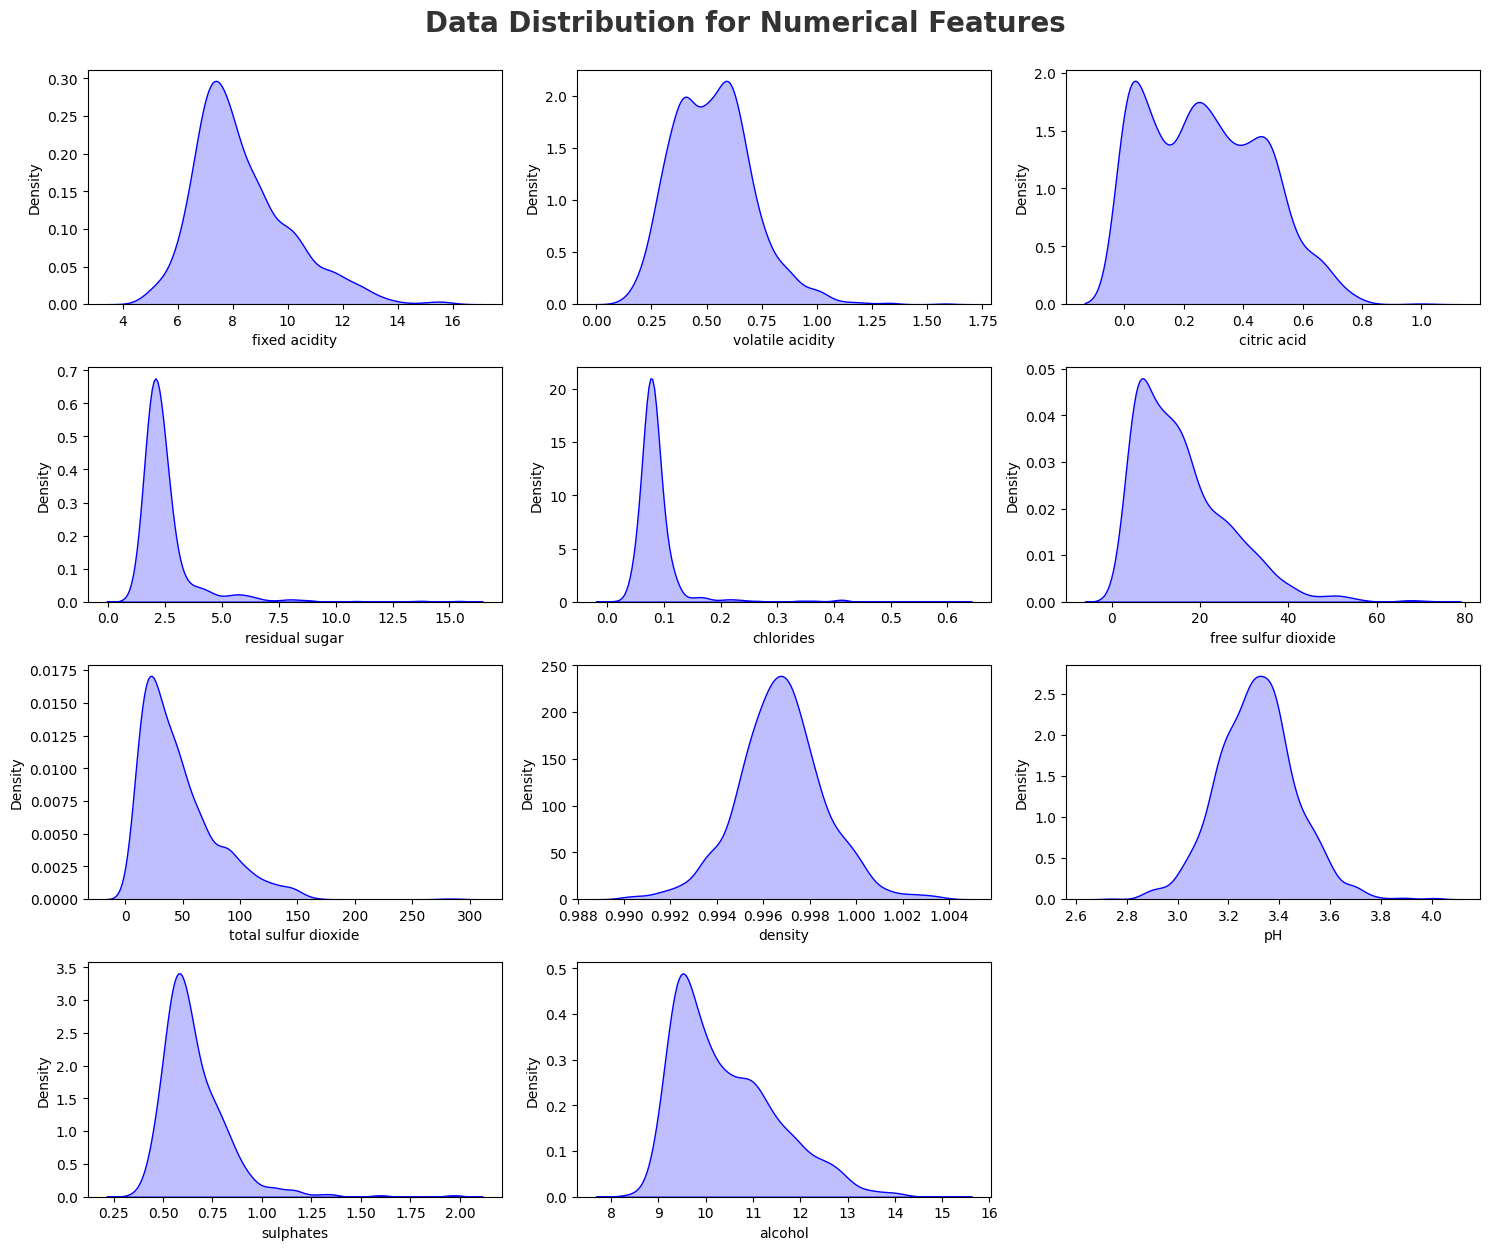

In [9]:
# Data Distribution
plt.figure(figsize=(15, 15))
plt.suptitle('Data Distribution for Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df[numeric_features[i]],shade=True, color='b')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

In [12]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


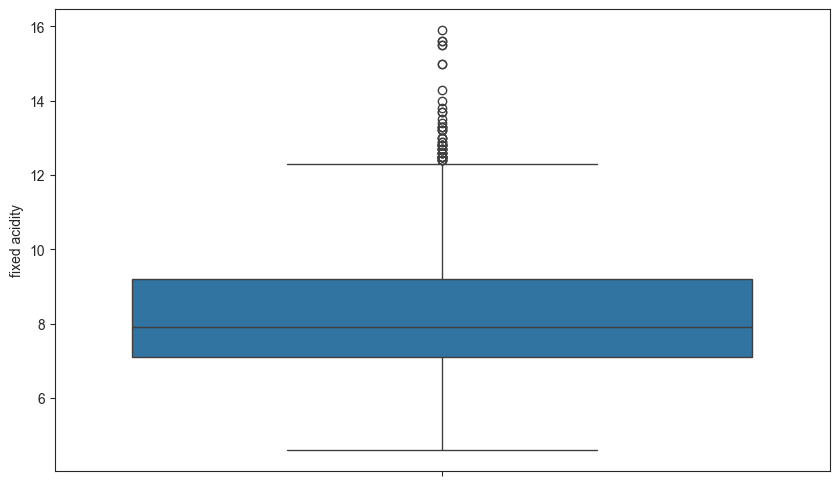

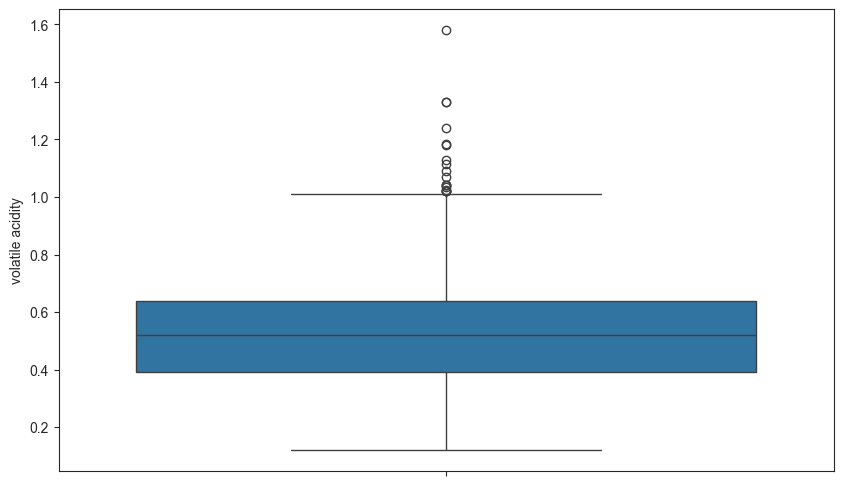

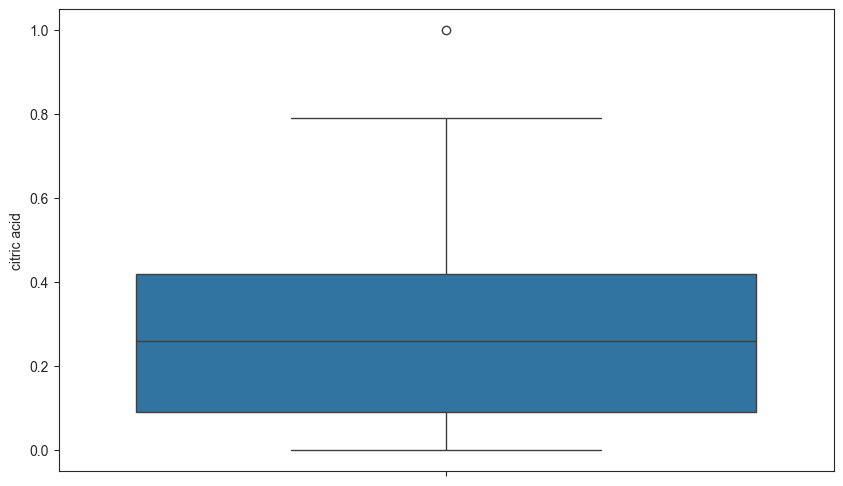

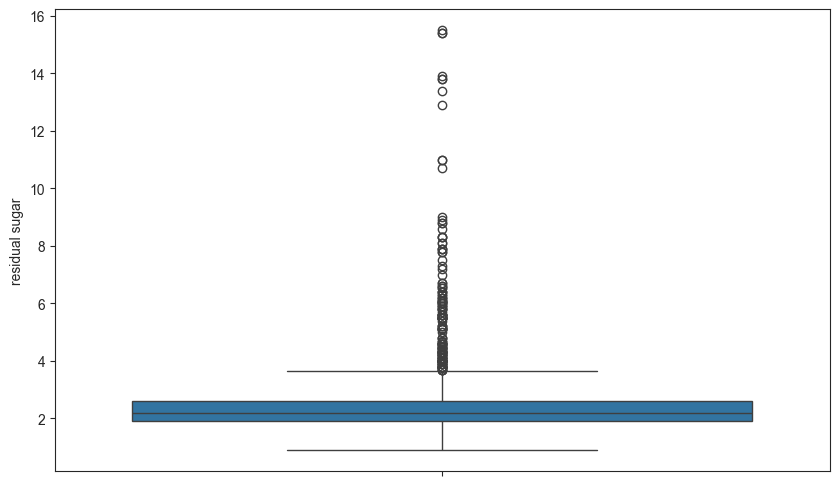

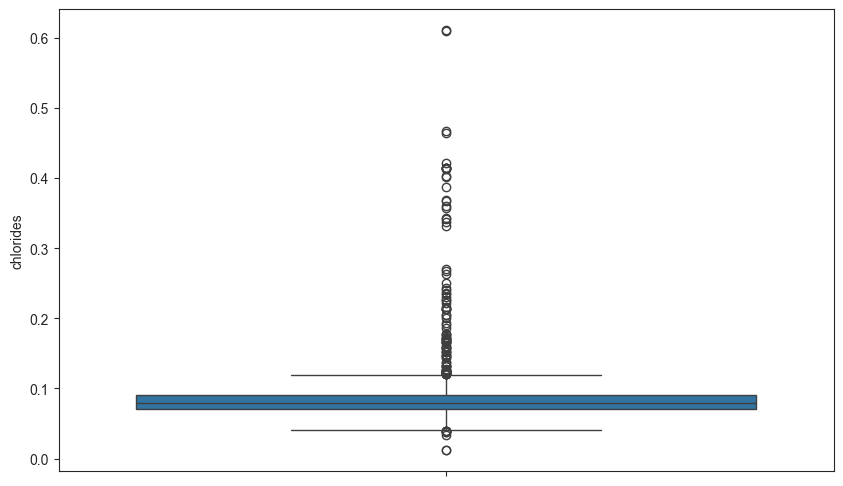

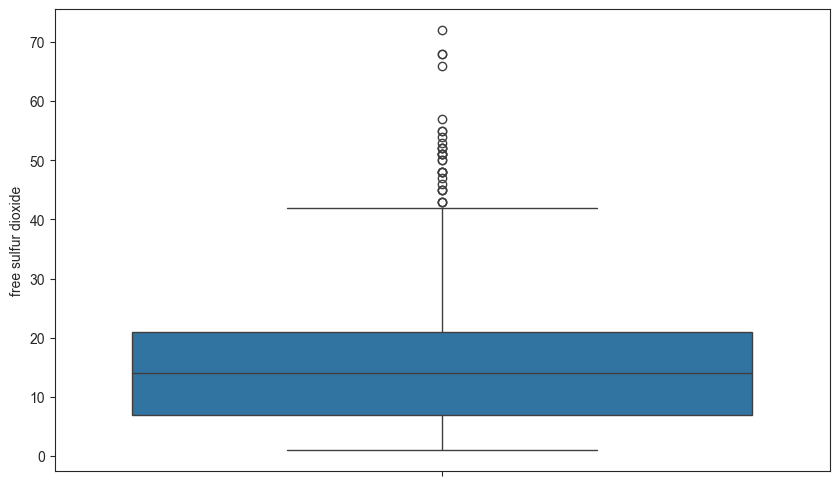

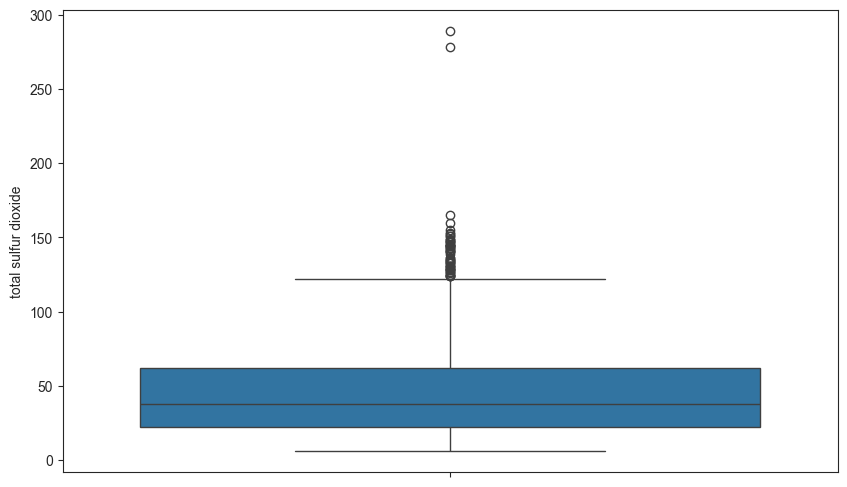

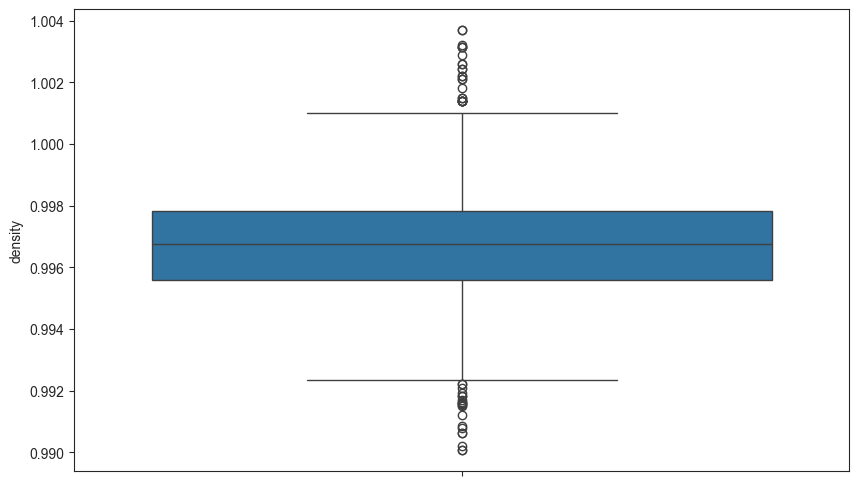

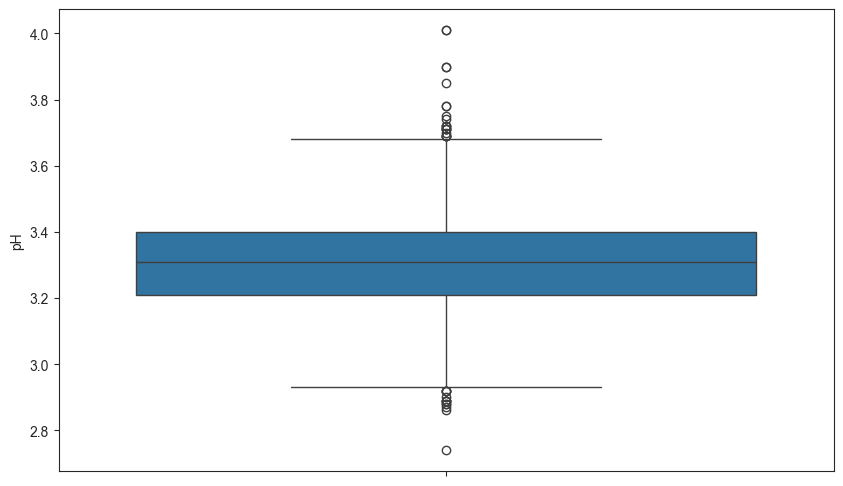

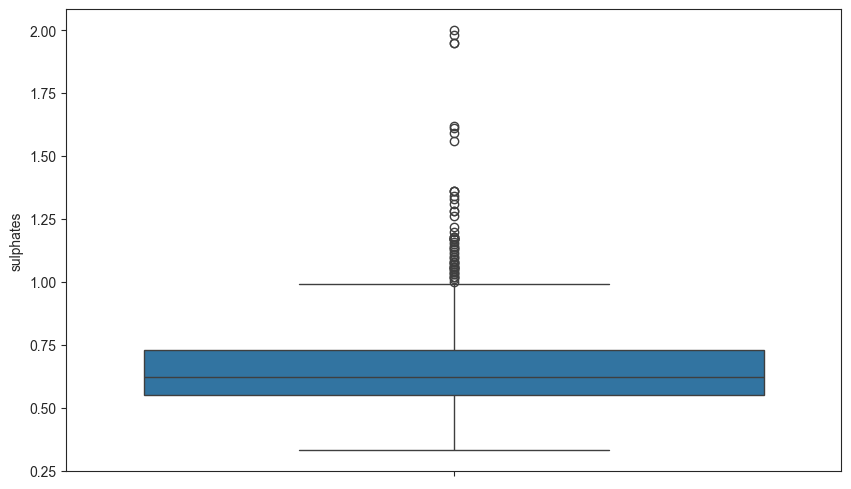

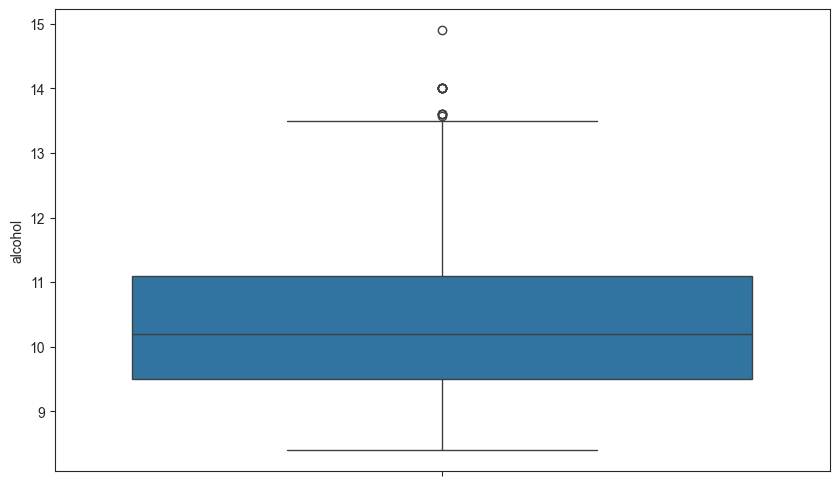

In [10]:
# numerical_features outlier distribution
for i in numeric_features:
        plt.figure(figsize=(10,6))
        sns.set_style('ticks')
        ax = sns.boxplot(df[i])

In [11]:
# skewness of numerical features
df[numeric_features].skew()

fixed acidity           0.982751
volatile acidity        0.671593
citric acid             0.318337
residual sugar          4.540655
chlorides               5.680347
free sulfur dioxide     1.250567
total sulfur dioxide    1.515531
density                 0.071288
pH                      0.193683
sulphates               2.428672
alcohol                 0.860829
dtype: float64

**Insighs**
 
-     SkewnessValue	        Interpretation
-   < -1 or > 1	             Highly Skewed 
-   -1 to -0.5 or 0.5 to 1	 Moderately Skewed 
-    -0.5 to 0.5	         Approximately Normal 

    - From EDA we have seen that Fixed Acidity, Volatile Acidity and Citric Acid were positively skewed — possibly due to outliers pulling the distribution to the right, and can be handled using Power Transformer or Log Transformer.

    - Chlorides (skewness = 5.68) and Residual Sugar (skewness = 4.54) are the most severely skewed features in the entire dataset — these extreme values strongly suggest the presence of significant outliers that must be treated before model training.

    - Sulphates (skewness = 2.43), Total Sulfur Dioxide (1.52), and Free Sulfur Dioxide (1.25) are also highly skewed and will benefit from transformation to bring them closer to a normal distribution.

    - Density (0.07) and pH (0.19) are the most normally distributed features, requiring no transformation — they are already well-suited for model input.

    - Alcohol (0.86) and Volatile Acidity (0.67) fall in the moderate skewness range — a mild transformation may help improve model performance slightly.

- Overall, 8 out of 11 features show some level of skewness, which confirms that feature transformation is a necessary step in the preprocessing pipeline before training the model.

    - Severe Skewness  (> 2)  → Log Transform or PowerTransformer (Yeo-Johnson)
    - High Skewness  (1 – 2)  → Square Root Transform or PowerTransformer
    - Moderate Skewness (0.5 – 1) → Mild transformation or keep as-is
    - Normal (< 0.5)           → No transformation needed 

#### Checking the power transformer on outlier columns

In [24]:

outlier_feature = [
    'fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates']


In [25]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(standardize=False)


In [26]:
# store only outlier data of two hight skiew numerical columns
outlier_data = df[outlier_feature]

In [27]:
outlier_data.head()

,fixed acidity,volatile acidity,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,sulphates
0,0.965601,0.434520,0.434345,0.040250,2.715988,3.710526,0.206762
1,0.972687,0.498508,0.454268,0.044648,3.662894,4.439253,0.217431
2,0.972687,0.457142,0.447288,0.043614,3.062287,4.205195,0.215122
3,1.015099,0.224548,0.434345,0.040006,3.206108,4.319267,0.208830
4,0.965601,0.434520,0.434345,0.040250,2.715988,3.710526,0.206762


In [28]:
df['fixed acidity']

0       0.965601
1       0.972687
2       0.972687
3       1.015099
4       0.965601
          ...   
1594    0.939948
1595    0.932234
1596    0.942387
1597    0.932234
1598    0.934874
Name: fixed acidity, Length: 1599, dtype: float64

In [29]:
# Transform the two high skew columns using PowerTransformer Technique
df[outlier_feature] = pt.fit_transform(df[outlier_feature])

In [30]:
# outlier Transform column
df['fixed acidity']

0       0.944075
1       0.950878
2       0.950878
3       0.991564
4       0.944075
          ...   
1594    0.919435
1595    0.912022
1596    0.921778
1597    0.912022
1598    0.914559
Name: fixed acidity, Length: 1599, dtype: float64

In [31]:
# outlier Transform column
df['chlorides']

0       0.044825
1       0.050312
2       0.049011
3       0.044524
4       0.044825
          ...   
1594    0.048547
1595    0.040117
1596    0.044825
1597    0.044524
1598    0.041926
Name: chlorides, Length: 1599, dtype: float64

In [32]:
# See outlier Data
df_outlier = pd.DataFrame(outlier_data, columns=outlier_feature)

In [33]:
df_outlier.head()

,fixed acidity,volatile acidity,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,sulphates
0,0.965601,0.434520,0.434345,0.040250,2.715988,3.710526,0.206762
1,0.972687,0.498508,0.454268,0.044648,3.662894,4.439253,0.217431
2,0.972687,0.457142,0.447288,0.043614,3.062287,4.205195,0.215122
3,1.015099,0.224548,0.434345,0.040006,3.206108,4.319267,0.208830
4,0.965601,0.434520,0.434345,0.040250,2.715988,3.710526,0.206762


In [34]:
# After Transforming the outlier then the Columns look like
df[outlier_feature].skew()

# NOTE-> Reduce the skewness

fixed acidity           0.000177
volatile acidity       -0.003170
residual sugar          0.005197
chlorides               0.027006
free sulfur dioxide    -0.041322
total sulfur dioxide   -0.033498
sulphates               0.000170
dtype: float64

<font size=3>Report</font>

<font size=3>After applying PowerTransformer (Yeo-Johnson), all 7 skewed features now have skewness values extremely close to zero, confirming a near-perfect normal distribution across all transformed features.</font>

<font size=3>The most dramatic improvements were seen in Chlorides (5.68 → 0.027) and Residual Sugar (4.54 → 0.005) — both of which were severely skewed before transformation and are now virtually normally distributed.</font>

<font size=3>Features like Free Sulfur Dioxide and Total Sulfur Dioxide now show slight negative skewness (-0.04 and -0.03), which is negligible and well within the acceptable normal range (±0.5).</font>

<font size=3>The PowerTransformer has successfully normalized all targeted features, making the dataset significantly more suitable for linear models like ElasticNet, which assume normally distributed input features.</font>

<font size=3>Combined with the already normal features (Density, pH, Citric Acid, Alcohol), the dataset is now well-prepared for feature scaling and model training.</font>

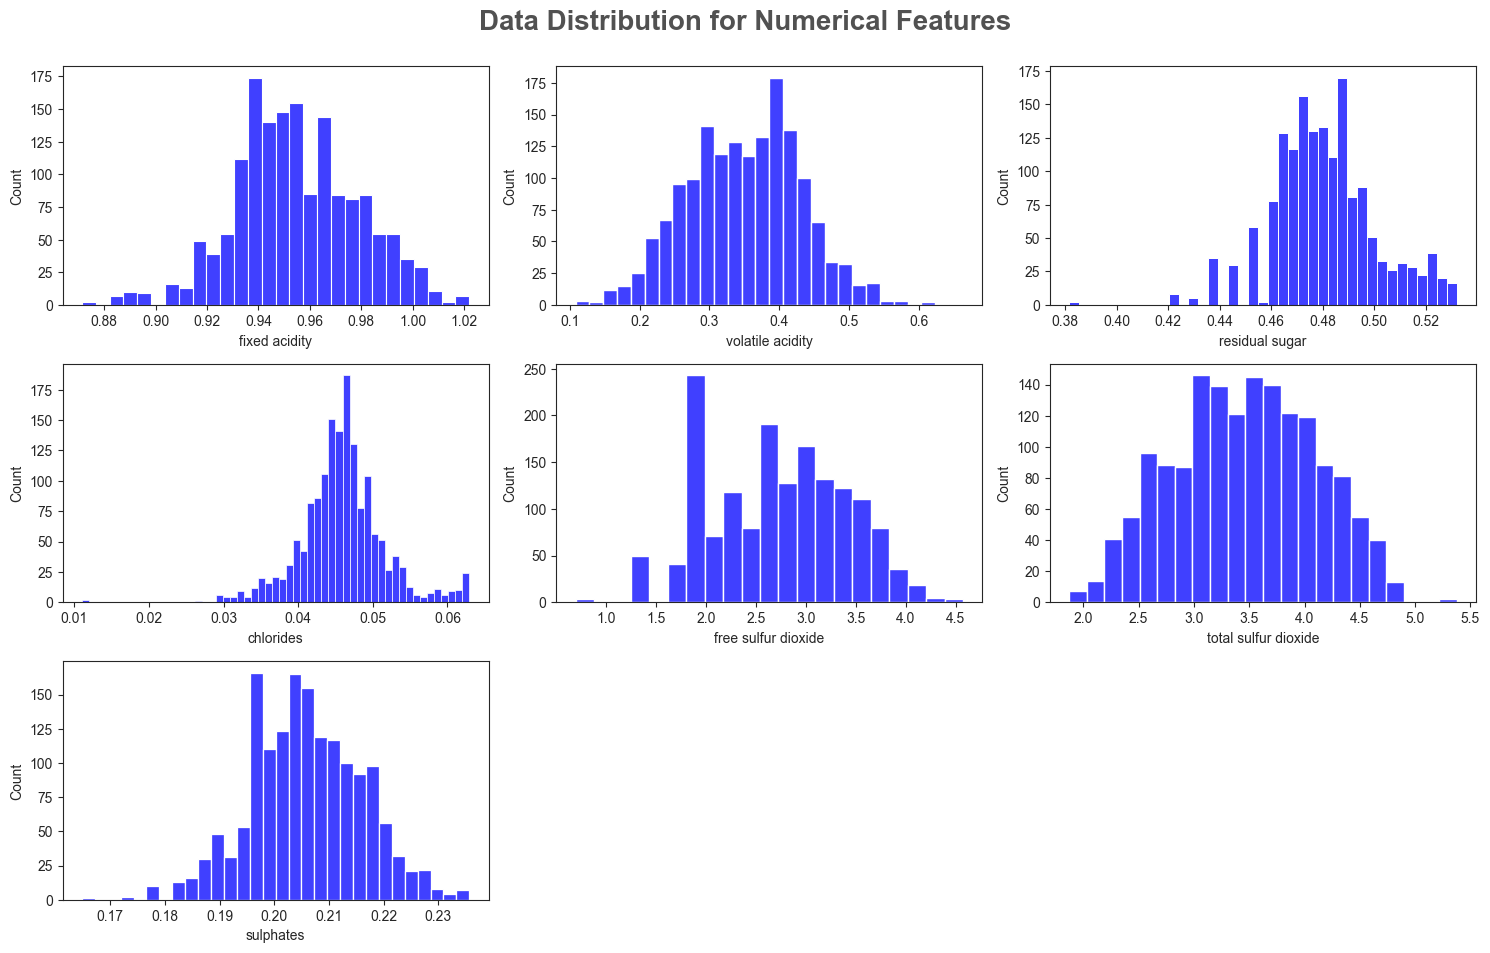

In [35]:
# After Transforming the outlier then the Columns look like
plt.figure(figsize=(15, 15))
plt.suptitle('Data Distribution for Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(outlier_feature)):
    plt.subplot(5, 3, i+1)
    sns.histplot(x=df[outlier_feature[i]], color='b')
    plt.xlabel(outlier_feature[i])
    plt.tight_layout()


**Insights**
 - Power transformer does a better job at overcoming skewness and handling outliers

**Why outliers?**
* Data Entry error : Human error.
* Measurement error: Instrument error.
* Natural error: it will be Real life data.
* Intentional error: People give wrong inputs

**Impact of Outliers ?**
* Ouliers can very high impact on few Machine learning models.
* Can Cause bias in the output.

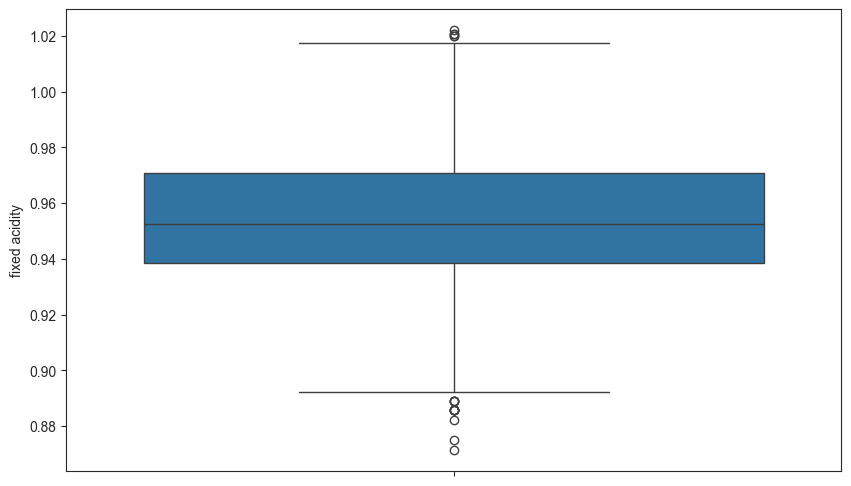

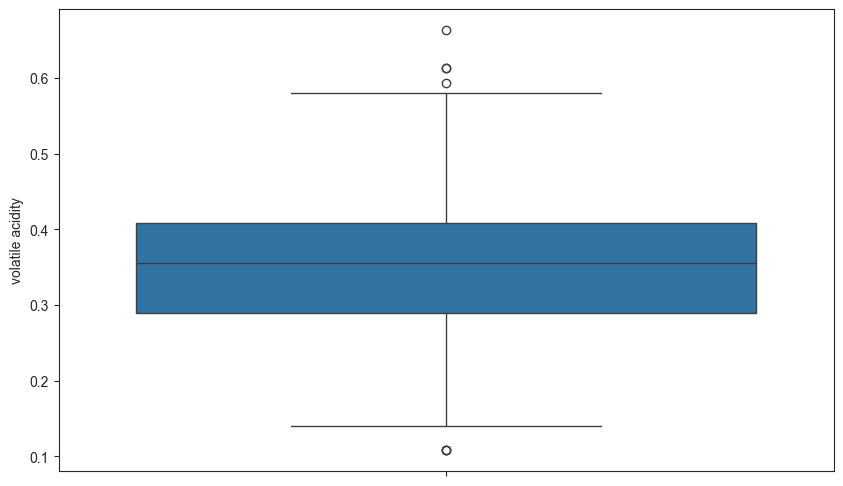

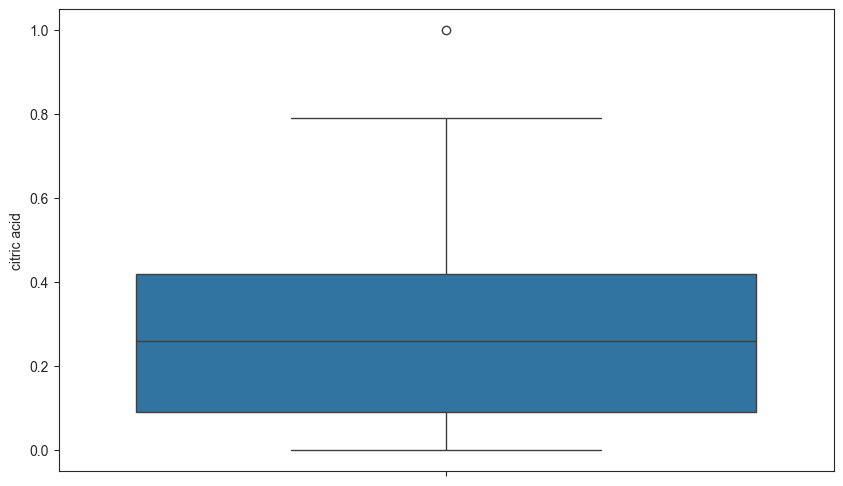

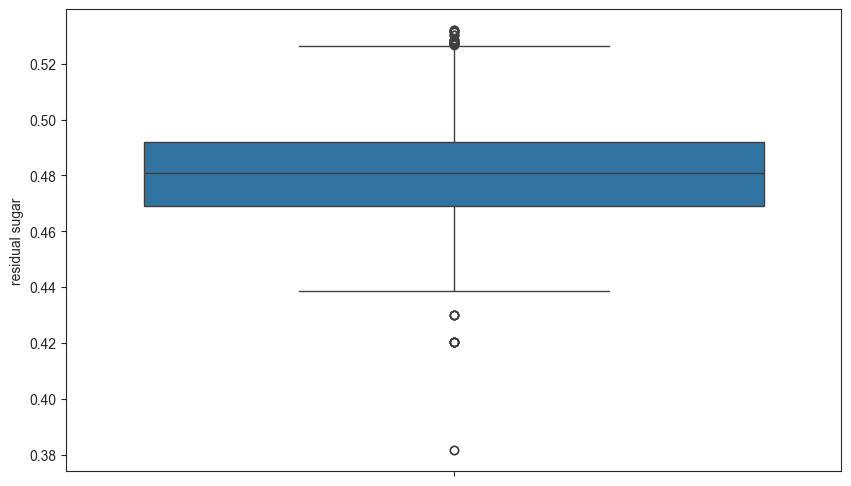

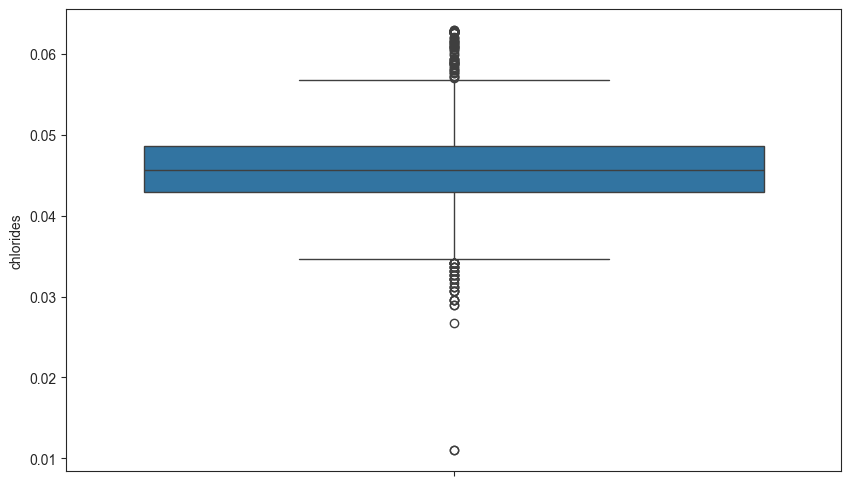

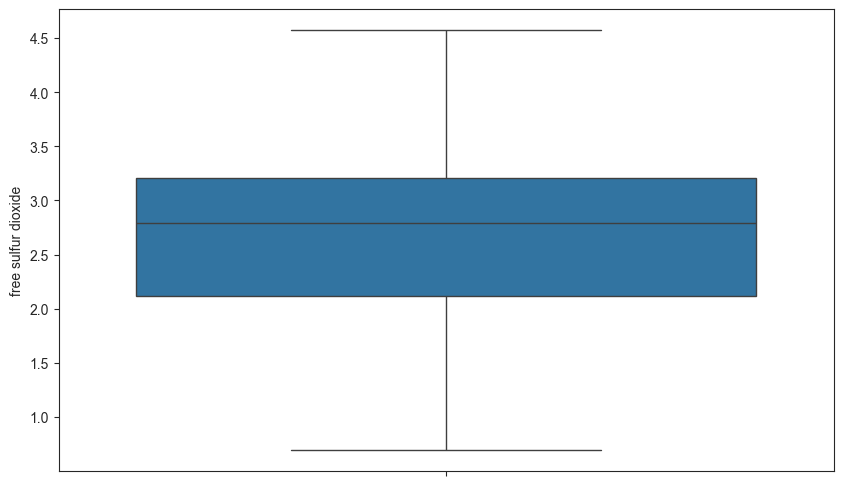

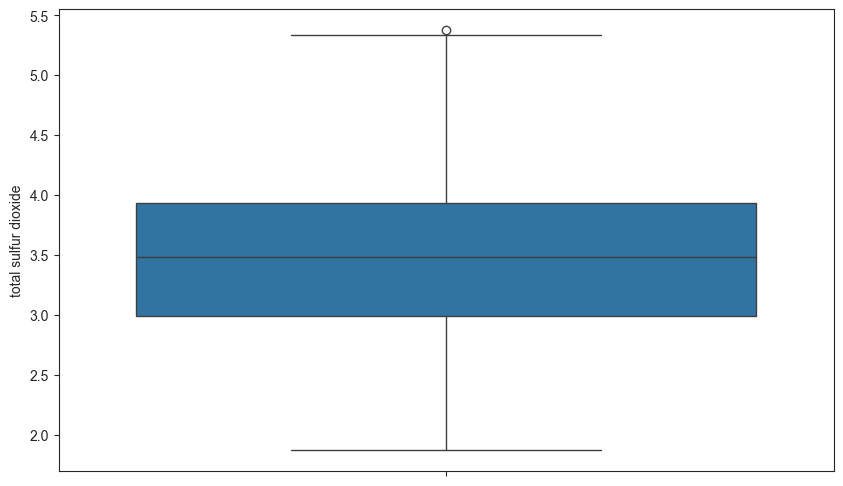

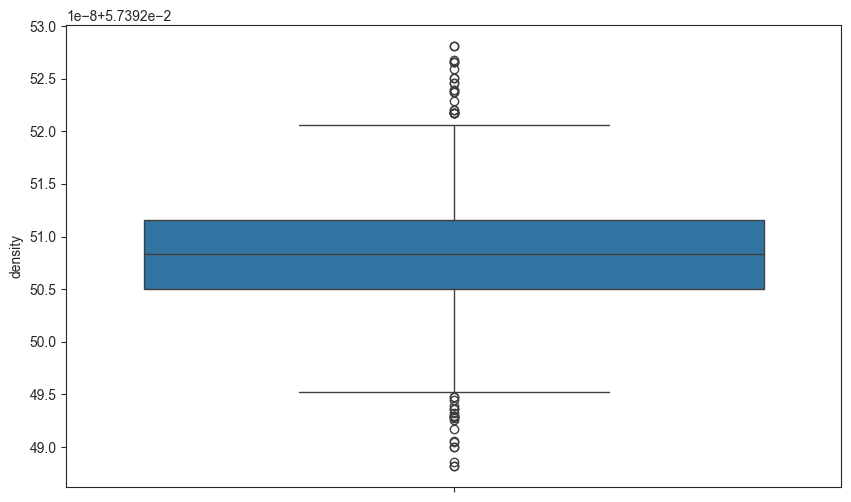

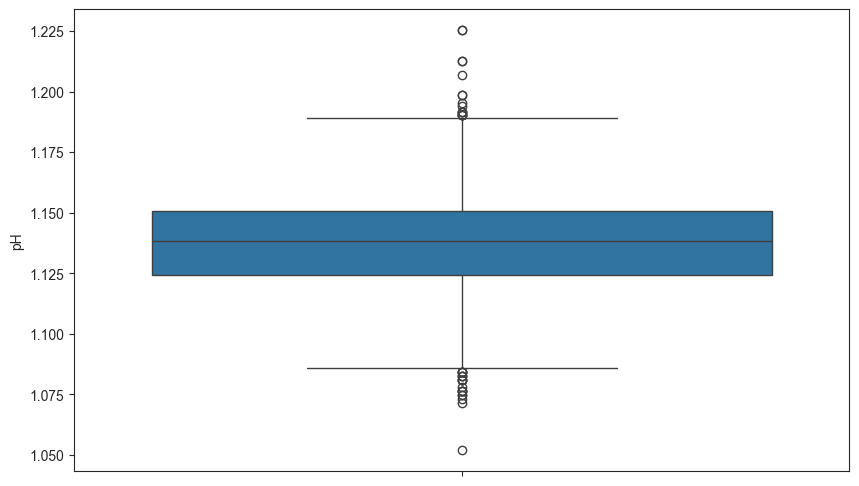

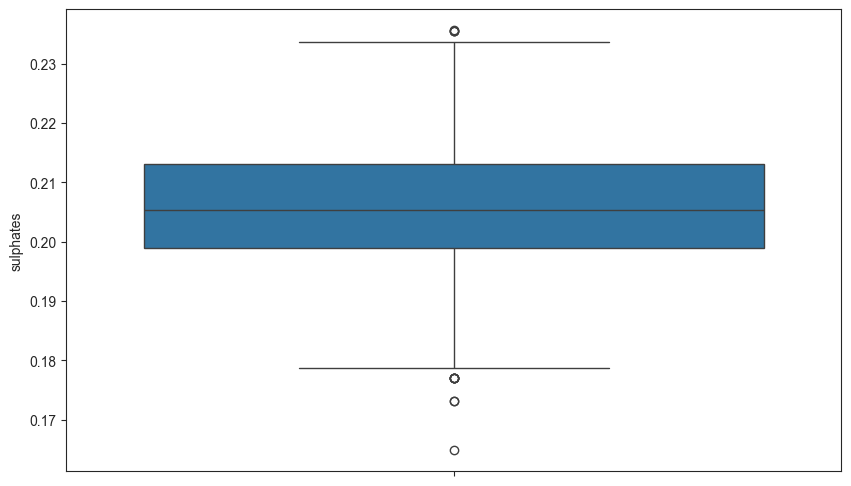

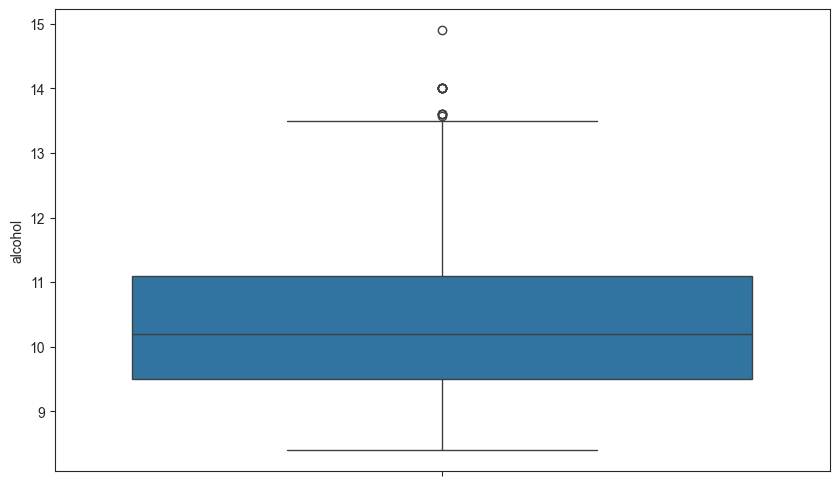

In [36]:
# After 
for i in numeric_features:
    plt.figure(figsize=(10,6))
    sns.set_style('ticks')
    ax = sns.boxplot(df[i])

In [37]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.944075,0.431464,0.0,0.468948,0.044825,2.549607,3.383410,0.057393,1.165072,0.199934,9.4,5
1,0.950878,0.494553,0.0,0.491998,0.050312,3.394190,4.006723,0.057393,1.122948,0.209911,9.8,5


#### Removing outliers from Target Column
* Because most model would perform better on noiseless data, as Outlier might skew the findings of your model in one direction

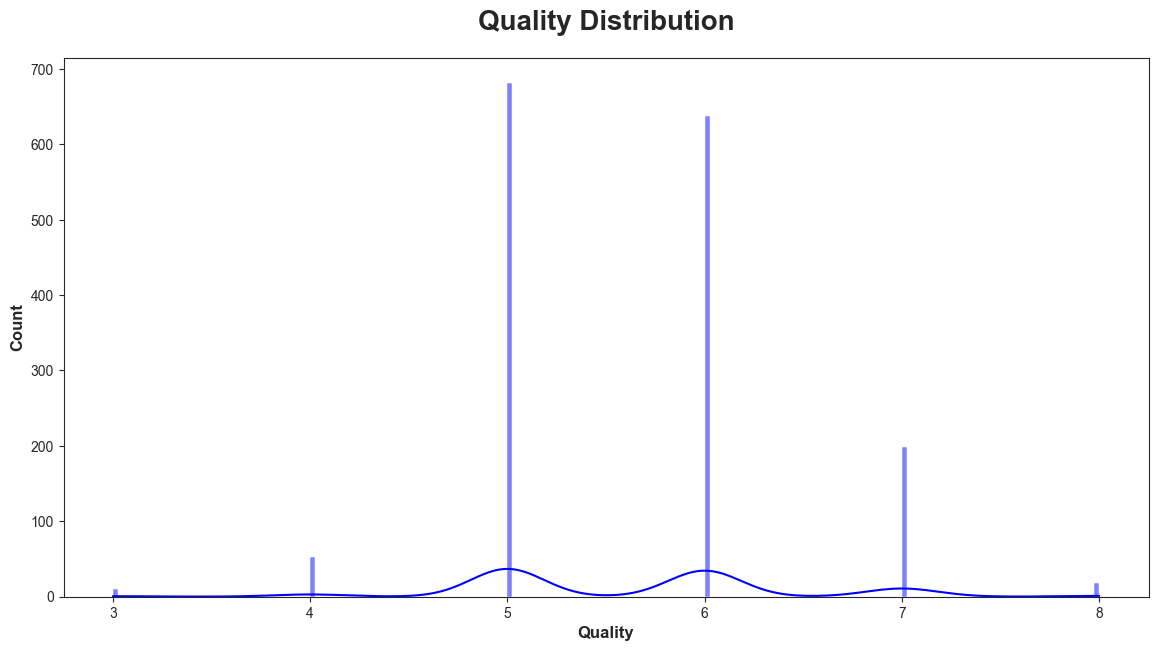

In [38]:
# Target columns distribution
plt.subplots(figsize=(14,7))
sns.histplot(df['quality'], bins=200, kde=True, color = 'b')
plt.title("Quality Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Quality", weight="bold", fontsize=12)
plt.show()

- Need to apply transformation to target column to make it normally distributed. we use 1p to avoid `inf` values arise dued to `0` in the target column.

In [40]:
print(f"Skewness of quality: {df['quality'].skew().round(3)}")
print(f"Quality value counts:\n{df['quality'].value_counts().sort_index()}")

Skewness of quality: 0.218
Quality value counts:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


Target Skewness: 0.218
Target Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


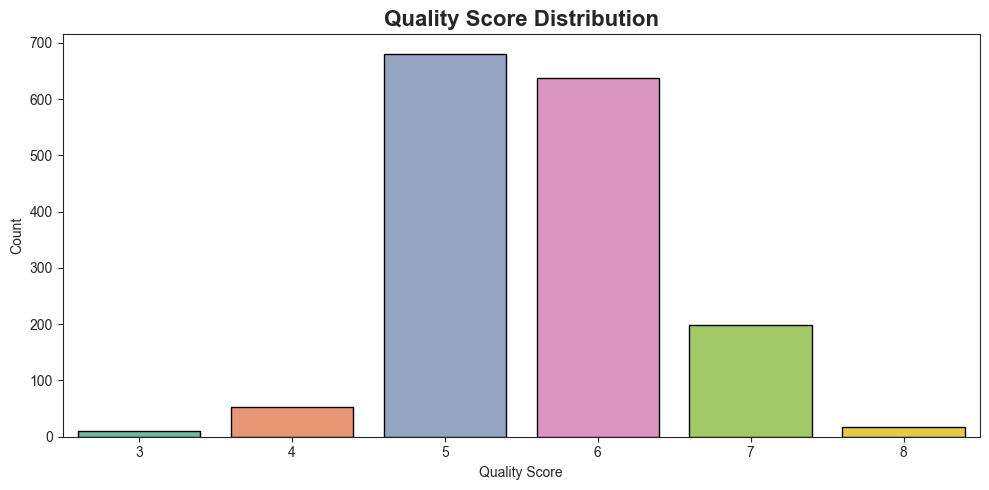

In [41]:
# NO transformation needed on target column

print("Target Skewness:", df['quality'].skew().round(3))
print("Target Distribution:")
print(df['quality'].value_counts().sort_index())

# Visualize
plt.figure(figsize=(10, 5))
sns.countplot(x=df['quality'], palette='Set2', ec='black')
plt.title("Quality Score Distribution", fontweight='bold', fontsize=16)
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Final Insight 
<font size=3>Report</font>

<font size=3>The Quality target column exhibits a skewness of 0.218, which falls well within the acceptable range for a normal distribution (±0.5).</font>

<font size=3>Because the target is already near-normal, no log transformation or power transformation is required, ensuring the model's predictions remain directly interpretable in the original 0–10 scale.</font>

<font size=3>The primary challenge for this column is class imbalance, as quality scores 5 and 6 account for 82% of the dataset, while scores 3 and 8 are significantly underrepresented.</font>

<font size=3>To address this, a Stratified Train-Test Split is recommended to ensure the model sees enough representative samples of the rare quality scores during the training phase.</font>

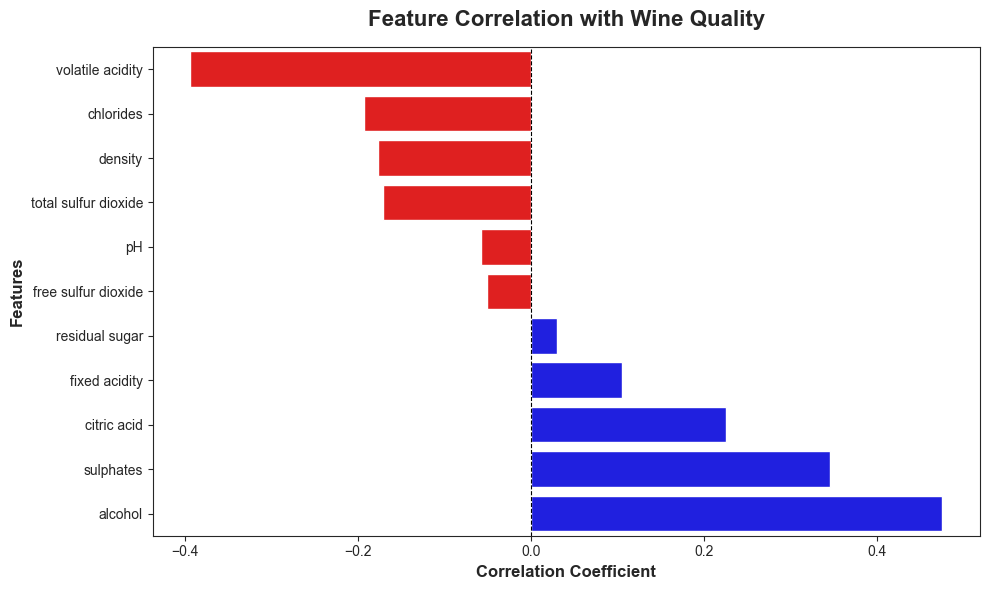


=== Correlation with Quality (Sorted) ===
volatile acidity       -0.394
chlorides              -0.193
density                -0.177
total sulfur dioxide   -0.171
pH                     -0.058
free sulfur dioxide    -0.051
residual sugar          0.030
fixed acidity           0.105
citric acid             0.226
sulphates               0.346
alcohol                 0.476
Name: quality, dtype: float64


In [42]:
# Correlation with target feature only
plt.figure(figsize=(10, 6))

target_corr = df.corr()[target_feature].drop(target_feature).sort_values()

colors = ['red' if val < 0 else 'blue' for val in target_corr.values]

sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    palette=colors
)

plt.title("Feature Correlation with Wine Quality",
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Correlation Coefficient", fontweight="bold", fontsize=12)
plt.ylabel("Features", fontweight="bold", fontsize=12)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

# Print correlation values
print("\n=== Correlation with Quality (Sorted) ===")
print(target_corr.round(3))

In [43]:
# Find highly correlated feature pairs
import itertools

threshold = 0.5
high_corr_pairs = []

for f1, f2 in itertools.combinations(numeric_features, 2):
    corr_val = df[f1].corr(df[f2])
    if abs(corr_val) >= threshold:
        high_corr_pairs.append((f1, f2, round(corr_val, 3)))

print("\n=== Highly Correlated Feature Pairs (|corr| >= 0.5) ===")
print(f"{'Feature 1':<25} {'Feature 2':<25} {'Correlation'}")
print("-" * 60)
for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{f1:<25} {f2:<25} {corr}")


=== Highly Correlated Feature Pairs (|corr| >= 0.5) ===
Feature 1                 Feature 2                 Correlation
------------------------------------------------------------
free sulfur dioxide       total sulfur dioxide      0.783
fixed acidity             pH                        -0.713
fixed acidity             density                   0.673
fixed acidity             citric acid               0.655
volatile acidity          citric acid               -0.57
citric acid               pH                        -0.544
density                   alcohol                   -0.501


<font size=3>Report</font>

<font size=3>Alcohol (+0.476) and Volatile Acidity (-0.394) are the two most influential features for predicting wine quality — higher alcohol improves quality while higher volatile acidity significantly reduces it.</font>

<font size=3>Free Sulfur Dioxide and Total Sulfur Dioxide are highly correlated (0.783) with each other — Free Sulfur Dioxide has a negligible target correlation (-0.051) and may be a candidate for removal to reduce multicollinearity.</font>

<font size=3>Fixed Acidity shows strong correlations with pH (-0.713), Density (0.673), and Citric Acid (0.655) simultaneously — making it the most multicollinear feature in the dataset.</fonte>

<font size=3>Residual Sugar, Free Sulfur Dioxide, and pH show near-zero correlation with Quality — these features carry minimal linear predictive power and may have low importance in the final model.</font>

<font size=3>Since no single feature strongly dominates the target correlation (max = 0.476), this confirms that wine quality is driven by a combination of chemical properties — making ElasticNet regularization an ideal modeling choice for this dataset.</font>

### Model Building

In [44]:
# ---------------------------------------------------------------
# Data Manipulation
# ---------------------------------------------------------------
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# Data Splitting
# ---------------------------------------------------------------
from sklearn.model_selection import (
    train_test_split,        
    cross_val_score,         
    GridSearchCV,            
    RandomizedSearchCV       
)

# ---------------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------------
from sklearn.preprocessing import (
    StandardScaler,          
    PowerTransformer,        
    RobustScaler             
)

# ---------------------------------------------------------------
# Pipeline & ColumnTransformer
# ---------------------------------------------------------------
from sklearn.pipeline import Pipeline          
from sklearn.compose import ColumnTransformer  

# ---------------------------------------------------------------
# Models
# ---------------------------------------------------------------
from sklearn.linear_model import (
    ElasticNet,                        
    LinearRegression         
)

# ---------------------------------------------------------------
# Ensemble & Boosting Models
# ---------------------------------------------------------------
from sklearn.ensemble import (
    GradientBoostingRegressor,   
    RandomForestRegressor            
)

# XGBoost
from xgboost import XGBRegressor         

# ---------------------------------------------------------------
# Evaluation Metrics
# ---------------------------------------------------------------
from sklearn.metrics import (
    r2_score,                
    mean_absolute_error,     
    mean_squared_error       
)

# ---------------------------------------------------------------
# Model Saving
# ---------------------------------------------------------------
import joblib                

# ---------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# Warnings
# ---------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

## Step 1: Define Feature Groups (Based on Our EDA)

In [ ]:
# ---------------------------------------------------------------
# Feature Grouping based on Skewness Analysis
# ---------------------------------------------------------------

# Highly/Moderately skewed → PowerTransformer + StandardScaler
skewed_features = [
    'fixed acidity',          # skew = 0.98
    'volatile acidity',       # skew = 0.67
    'residual sugar',         # skew = 4.54
    'chlorides',              # skew = 5.68
    'free sulfur dioxide',    # skew = 1.25
    'total sulfur dioxide',   # skew = 1.52
    'sulphates'               # skew = 2.43
]

# Already normally distributed → StandardScaler only
normal_features = [
    'citric acid',            # skew = 0.32
    'density',                # skew = 0.07
    'pH',                     # skew = 0.19
    'alcohol'                 # skew = 0.86
]

print(f"Skewed Features : {len(skewed_features)}")
print(f"Normal Features : {len(normal_features)}")
print(f"Total Features  : {len(skewed_features) + len(normal_features)}")

Skewed Features : 7
Normal Features : 4
Total Features  : 11


## Step 2: Train-Test Split (Do This BEFORE Transformation)

In [51]:
# ---------------------------------------------------------------
# Split Features & Target
# ---------------------------------------------------------------
X = df.drop(columns=['quality'], axis=1)
y = df['quality']

# ---------------------------------------------------------------
# Stratified Train-Test Split
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

# Verify stratification worked
print("\n=== Train Distribution ===")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\n=== Test Distribution ===")
print(y_test.value_counts(normalize=True).sort_index().round(3))

X_train : (1279, 11)
X_test  : (320, 11)
y_train : (1279,)
y_test  : (320,)

=== Train Distribution ===
quality
3    0.006
4    0.033
5    0.426
6    0.399
7    0.124
8    0.012
Name: proportion, dtype: float64

=== Test Distribution ===
quality
3    0.006
4    0.034
5    0.425
6    0.400
7    0.125
8    0.009
Name: proportion, dtype: float64


##  Step 3: Build Individual Pipelines

In [53]:
# ---------------------------------------------------------------
# Pipeline for SKEWED features
# PowerTransformer (Yeo-Johnson) → normalizes distribution
# StandardScaler                 → standardizes to mean=0, std=1
# ---------------------------------------------------------------
skewed_pipeline = Pipeline(steps=[
    ('power_transform', PowerTransformer(method='yeo-johnson', standardize=False)),
    ('scaler', StandardScaler())
])


# ---------------------------------------------------------------
# Pipeline for NORMAL features
# StandardScaler only → no transformation needed
# ---------------------------------------------------------------
normal_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

## Step 4: Combine with ColumnTransformer

In [54]:
# ---------------------------------------------------------------
# ColumnTransformer — applies different pipelines to different columns
# ---------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('skewed', skewed_pipeline, skewed_features),
        ('normal', normal_pipeline, normal_features)
    ],
    remainder='drop',        # drop any column not listed
    verbose_feature_names_out=False
)

# Keep output as pandas DataFrame (sklearn >= 1.2)
preprocessor.set_output(transform="pandas")

print(preprocessor)

ColumnTransformer(transformers=[('skewed',
                                 Pipeline(steps=[('power_transform',
                                                  PowerTransformer(standardize=False)),
                                                 ('scaler', StandardScaler())]),
                                 ['fixed acidity', 'volatile acidity',
                                  'residual sugar', 'chlorides',
                                  'free sulfur dioxide', 'total sulfur dioxide',
                                  'sulphates']),
                                ('normal',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['citric acid', 'density', 'pH', 'alcohol'])],
                  verbose_feature_names_out=False)


## Step 5: Fit & Transform

In [55]:
# ---------------------------------------------------------------
# Fit on TRAIN only → transform both TRAIN and TEST
# ---------------------------------------------------------------
X_train_transformed = preprocessor.fit_transform(X_train)   # fit + transform
X_test_transformed  = preprocessor.transform(X_test)        # transform only

print(f"X_train_transformed : {X_train_transformed.shape}")
print(f"X_test_transformed  : {X_test_transformed.shape}")

X_train_transformed.head()

X_train_transformed : (1279, 11)
X_test_transformed  : (320, 11)


,fixed acidity,volatile acidity,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,sulphates,citric acid,density,pH,alcohol
1542,-1.015055,1.673947,-0.633678,-0.907745,1.207908,0.012386,-0.588719,-1.303102,-1.090432,-0.032871,0.305611
1558,-0.845586,0.663363,2.188288,2.600924,2.594704,1.617444,-0.588719,0.288062,0.618414,-0.568938,-0.867817
344,1.809127,0.346887,0.558413,0.110508,-1.135913,-0.230694,0.945234,1.160636,2.059786,-1.258743,0.258674
924,0.336049,-0.236194,0.145140,-1.565311,0.065797,-0.418196,1.038960,-0.019905,-0.848740,-0.842172,0.728045
971,1.235466,-1.755328,-0.633678,-0.776564,-1.135913,-1.811135,1.327144,1.057980,0.280607,0.164677,0.446422


## Step 6: Verify the Transformation Worked

In [57]:
# ---------------------------------------------------------------
# Check skewness BEFORE vs AFTER
# ---------------------------------------------------------------
comparison = pd.DataFrame({
    'Before': X_train.skew().round(3),
    'After' : X_train_transformed.skew().round(3)
})
comparison['Improvement'] = (
    comparison['Before'].abs() - comparison['After'].abs()
).round(3)

print("=== Skewness Comparison ===")
display(comparison.sort_values('Before', key=abs, ascending=False))


# ---------------------------------------------------------------
# Check scaling (mean ≈ 0, std ≈ 1)
# ---------------------------------------------------------------
print("\n=== Scaling Verification ===")
print(pd.DataFrame({
    'Mean': X_train_transformed.mean().round(3),
    'Std' : X_train_transformed.std().round(3)
}))

=== Skewness Comparison ===


,Before,After,Improvement
alcohol,0.867,0.867,0.000
citric acid,0.304,0.304,0.000
chlorides,0.239,-0.031,0.208
residual sugar,0.127,-0.005,0.122
sulphates,0.084,0.001,0.083
free sulfur dioxide,-0.066,-0.048,0.018
total sulfur dioxide,-0.062,-0.040,0.022
pH,-0.055,-0.055,0.000
volatile acidity,0.045,-0.002,0.043
fixed acidity,-0.043,0.000,0.043



=== Scaling Verification ===
                      Mean  Std
fixed acidity          0.0  1.0
volatile acidity       0.0  1.0
residual sugar        -0.0  1.0
chlorides             -0.0  1.0
free sulfur dioxide   -0.0  1.0
total sulfur dioxide   0.0  1.0
sulphates             -0.0  1.0
citric acid            0.0  1.0
density                0.0  1.0
pH                     0.0  1.0
alcohol               -0.0  1.0


## Visualize Before vs After

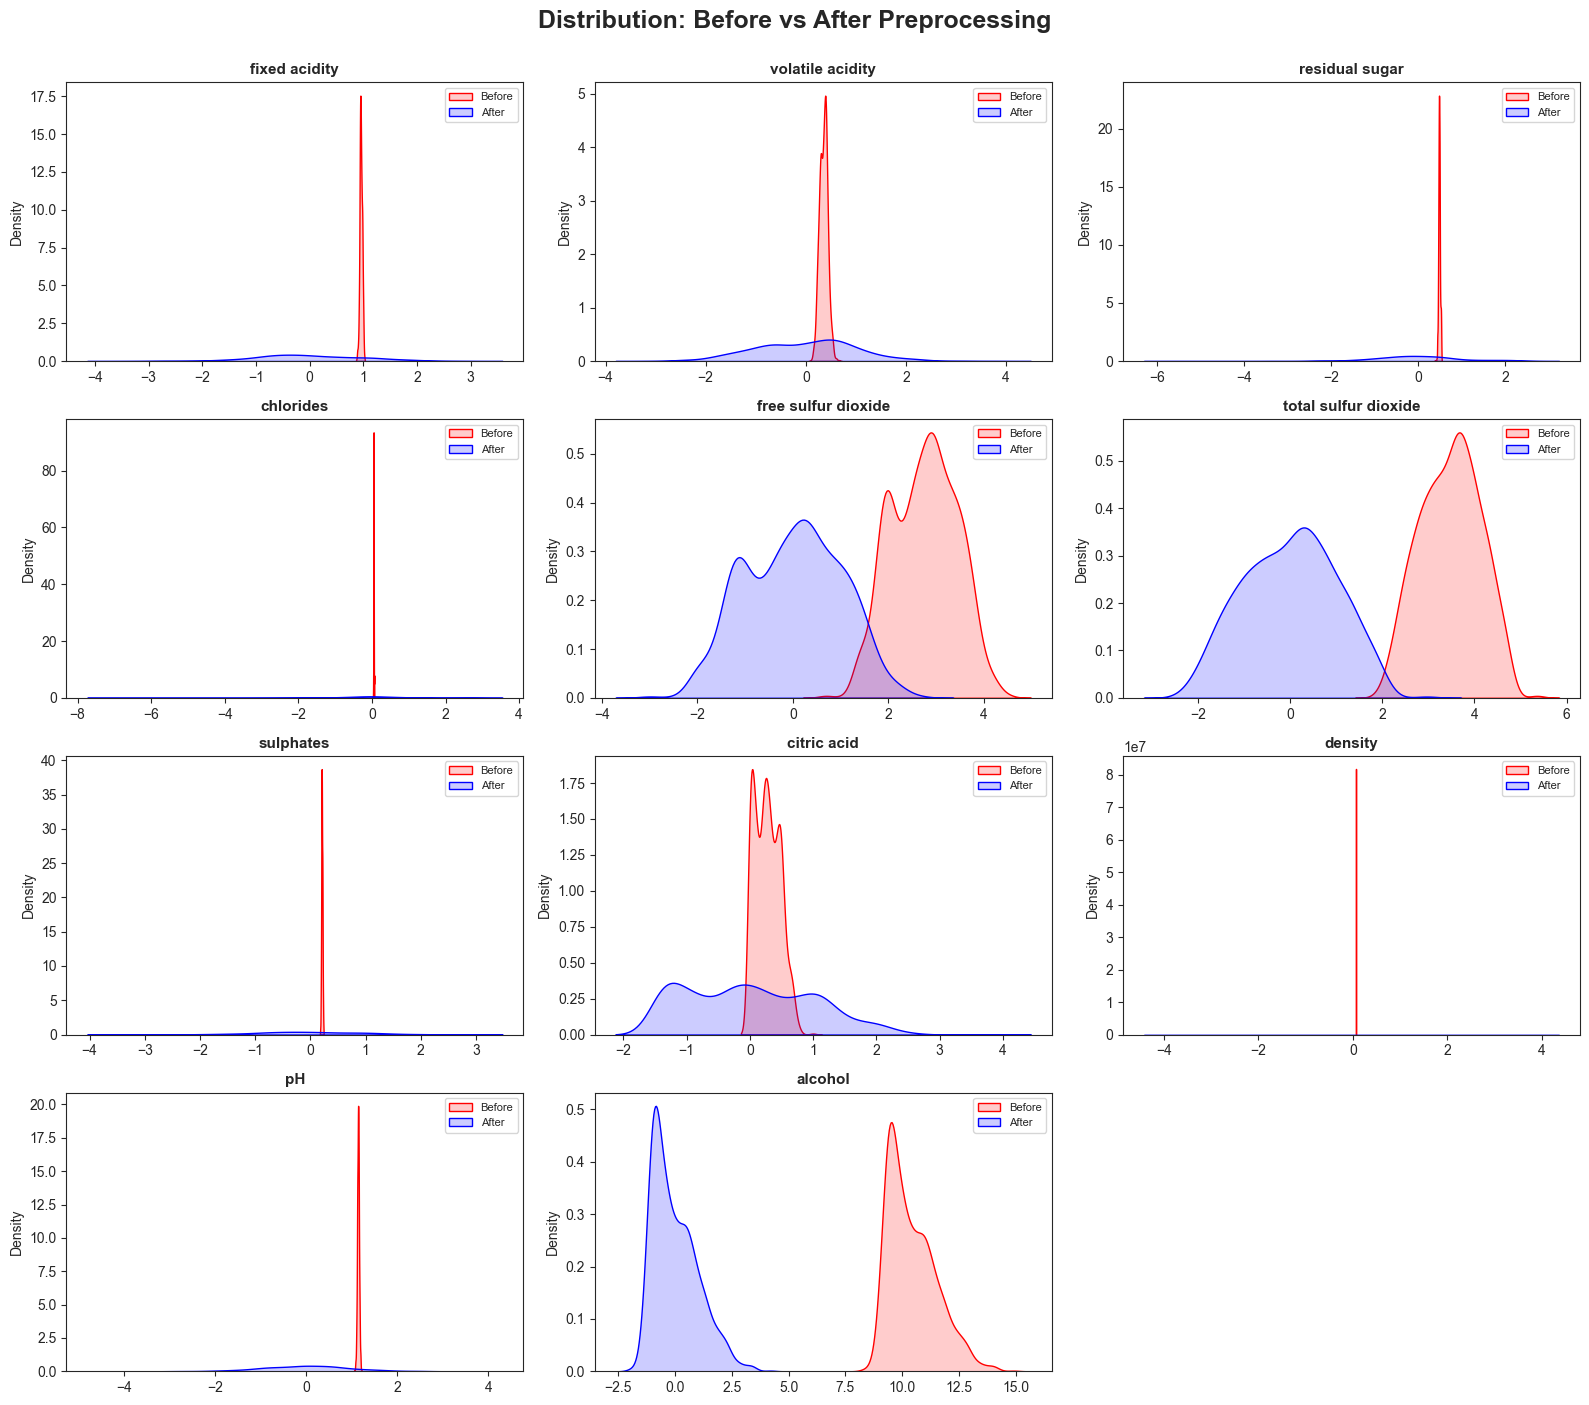

In [58]:
import math

all_features = skewed_features + normal_features
cols = 3
rows = math.ceil(len(all_features) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.5))
fig.suptitle('Distribution: Before vs After Preprocessing',
             fontsize=18, fontweight='bold', y=1.0)

axes = axes.flatten()

for i, feature in enumerate(all_features):
    sns.kdeplot(X_train[feature], color='red',
                label='Before', ax=axes[i], fill=True, alpha=0.2)
    sns.kdeplot(X_train_transformed[feature], color='blue',
                label='After', ax=axes[i], fill=True, alpha=0.2)
    axes[i].set_title(feature, fontweight='bold', fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(len(all_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

##  Step 7: Save the Preprocessor

In [60]:
# ---------------------------------------------------------------
# Save preprocessor for later use in prediction pipeline
# ---------------------------------------------------------------
import os

os.makedirs("artifacts", exist_ok=True)
joblib.dump(preprocessor, "artifacts/preprocessor.joblib")

print("Preprocessor saved to artifacts/preprocessor.joblib")

Preprocessor saved to artifacts/preprocessor.joblib


## Model Training & Comparison — Wine Quality

- **Regression Metrices**

In [63]:
# # functions which takes true and predicted values to calculate metrics
# def evaluate_reg(true, predicted):
#     mae = mean_absolute_error(true, predicted)
#     mse = mean_squared_error(true, predicted)
#     rmse = np.sqrt(mean_squared_error(true, predicted))
#     r2_square = r2_score(true, predicted)
#     return mae, rmse, r2_square

## Step 1: Define All Models

In [61]:
# ---------------------------------------------------------------
# Define All Models
# ---------------------------------------------------------------
models = {
    "Linear Regression": LinearRegression(),
    
    "ElasticNet": ElasticNet(
        alpha=1.0,
        l1_ratio=0.5,
        random_state=42                                    
        ),
    
    "Random Forest" : RandomForestRegressor(
         n_estimators=100,
         random_state=42,
         n_jobs=-1
      ),
    
    "Gradient Boosting" : GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    "XGBoost" : XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )

}

## Step 2: Define Evaluation Function

In [64]:
# ---------------------------------------------------------------
# Evaluation Function
# ---------------------------------------------------------------
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """
    Train and evaluate a single model.
    Returns a dictionary of metrics.
    """
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    # Cross Validation
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    
    # Metrics
    metrics = {
        "Model"          : model_name,
        
        # Train Metrics
        "Train R²"       : round(r2_score(y_train, y_pred_train), 4),
        "Train MAE"      : round(mean_absolute_error(y_train, y_pred_train), 4),
        "Train RMSE"     : round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 4),
        
        # Test Metrics
        "Test R²"        : round(r2_score(y_test, y_pred_test), 4),
        "Test MAE"       : round(mean_absolute_error(y_test, y_pred_test), 4),
        "Test RMSE"      : round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 4),
        
        # Cross Validation
        "CV Mean R²"     : round(cv_scores.mean(), 4),
        "CV Std"         : round(cv_scores.std(), 4)
    }
    
    return metrics, model

## Step 3: Train & Evaluate All Models

In [65]:
# ---------------------------------------------------------------
# Train & Evaluate All Models
# ---------------------------------------------------------------
results      = []
trained_models = {}

print("=" * 60)
print("       MODEL TRAINING & EVALUATION")
print("=" * 60)

for name, model in models.items():
    print(f"\n⏳ Training: {name}...")
    
    metrics, trained_model = evaluate_model(
        name, model,
        X_train_transformed, X_test_transformed,
        y_train, y_test
    )
    
    results.append(metrics)
    trained_models[name] = trained_model
    
    print(f" ✅ Done! Test R²: {metrics['Test R²']} | Test MAE: {metrics['Test MAE']} | Test RMSE: {metrics['Test RMSE']}")

print("\n" + "=" * 60)
print("       ALL MODELS TRAINED SUCCESSFULLY! ✅")
print("=" * 60)

       MODEL TRAINING & EVALUATION

⏳ Training: Linear Regression...
 ✅ Done! Test R²: 0.3864 | Test MAE: 0.4796 | Test RMSE: 0.6292

⏳ Training: ElasticNet...
 ✅ Done! Test R²: -0.0001 | Test MAE: 0.6812 | Test RMSE: 0.8033

⏳ Training: Random Forest...
 ✅ Done! Test R²: 0.5086 | Test MAE: 0.416 | Test RMSE: 0.5631

⏳ Training: Gradient Boosting...
 ✅ Done! Test R²: 0.4239 | Test MAE: 0.4711 | Test RMSE: 0.6097

⏳ Training: XGBoost...
 ✅ Done! Test R²: 0.4859 | Test MAE: 0.4176 | Test RMSE: 0.5759

       ALL MODELS TRAINED SUCCESSFULLY! ✅


## Step 4: Display Results

In [66]:
# ---------------------------------------------------------------
# Display Results as DataFrame
# ---------------------------------------------------------------
results_df = (
    pd.DataFrame(results)
    .sort_values("Test R²", ascending=False)
    .reset_index(drop=True)
)

# Highlight best model
results_df.index = results_df.index + 1
display(results_df)

# Best model
best_model_name = results_df.iloc[0]["Model"]
print(f"\n Best Model: {best_model_name}")
print(f"   Test R²  : {results_df.iloc[0]['Test R²']}")
print(f"   Test MAE : {results_df.iloc[0]['Test MAE']}")
print(f"   Test RMSE: {results_df.iloc[0]['Test RMSE']}")

,Model,Train R²,Train MAE,Train RMSE,Test R²,Test MAE,Test RMSE,CV Mean R²,CV Std
1,Random Forest,0.9284,0.1544,0.2163,0.5086,0.4160,0.5631,0.4583,0.0459
2,XGBoost,0.9264,0.1584,0.2193,0.4859,0.4176,0.5759,0.4302,0.0446
3,Gradient Boosting,0.6369,0.3826,0.4871,0.4239,0.4711,0.6097,0.4053,0.0470
4,Linear Regression,0.3718,0.4954,0.6407,0.3864,0.4796,0.6292,0.3602,0.0477
5,ElasticNet,0.0000,0.6836,0.8083,-0.0001,0.6812,0.8033,-0.0027,0.0017



 Best Model: Random Forest
   Test R²  : 0.5086
   Test MAE : 0.416
   Test RMSE: 0.5631


## Step 5: Visualize Model Comparison

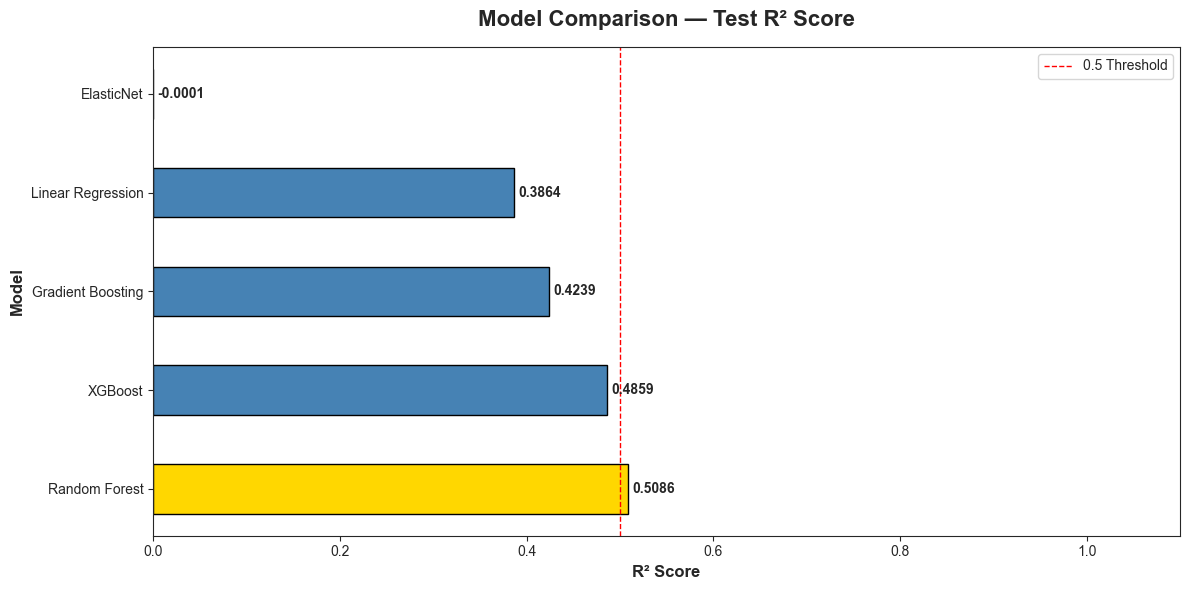

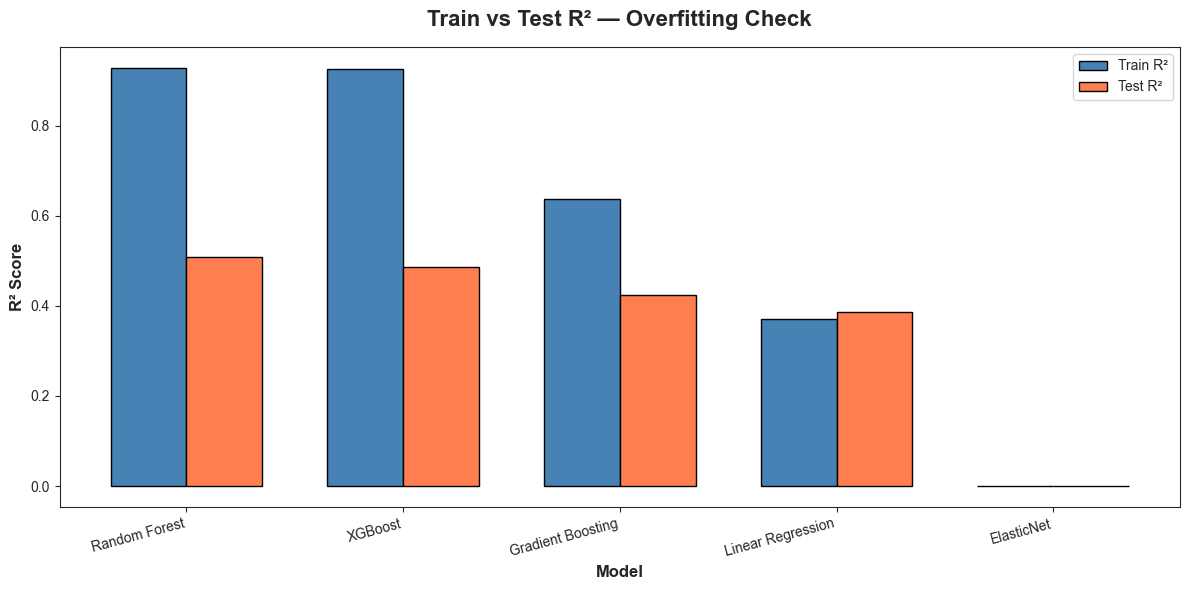

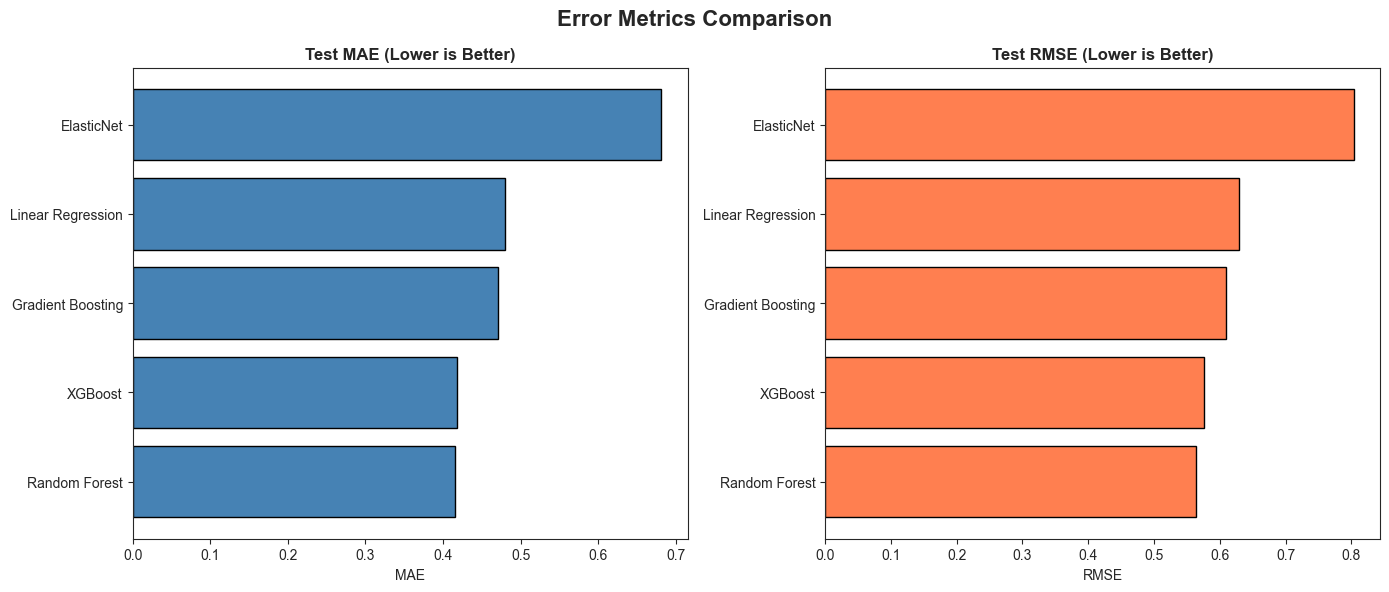

In [67]:
# ---------------------------------------------------------------
# Visualization 1: Test R² Comparison
# ---------------------------------------------------------------
plt.figure(figsize=(12, 6))
colors = ['gold' if i == 0 else 'steelblue' 
          for i in range(len(results_df))]

bars = plt.barh(
    results_df["Model"],
    results_df["Test R²"],
    color=colors,
    edgecolor='black',
    height=0.5
)

# Add value labels
for bar, val in zip(bars, results_df["Test R²"]):
    plt.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center',
        fontweight='bold'
    )

plt.title("Model Comparison — Test R² Score",
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("R² Score", fontweight='bold', fontsize=12)
plt.ylabel("Model", fontweight='bold', fontsize=12)
plt.xlim(0, 1.1)
plt.axvline(x=0.5, color='red', linestyle='--',
            linewidth=1, label='0.5 Threshold')
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------
# Visualization 2: Train vs Test R² (Overfitting Check)
# ---------------------------------------------------------------
x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, results_df["Train R²"],
        width, label='Train R²', color='steelblue', ec='black')
plt.bar(x + width/2, results_df["Test R²"],
        width, label='Test R²', color='coral', ec='black')

plt.title("Train vs Test R² — Overfitting Check",
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Model", fontweight='bold', fontsize=12)
plt.ylabel("R² Score", fontweight='bold', fontsize=12)
plt.xticks(x, results_df["Model"], rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------
# Visualization 3: MAE & RMSE Comparison
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Error Metrics Comparison",
             fontsize=16, fontweight='bold')

# MAE
axes[0].barh(results_df["Model"], results_df["Test MAE"],
             color='steelblue', edgecolor='black')
axes[0].set_title("Test MAE (Lower is Better)",
                  fontweight='bold')
axes[0].set_xlabel("MAE")

# RMSE
axes[1].barh(results_df["Model"], results_df["Test RMSE"],
             color='coral', edgecolor='black')
axes[1].set_title("Test RMSE (Lower is Better)",
                  fontweight='bold')
axes[1].set_xlabel("RMSE")

plt.tight_layout()
plt.show()

##  Step 6: Actual vs Predicted Plot (Best Model)

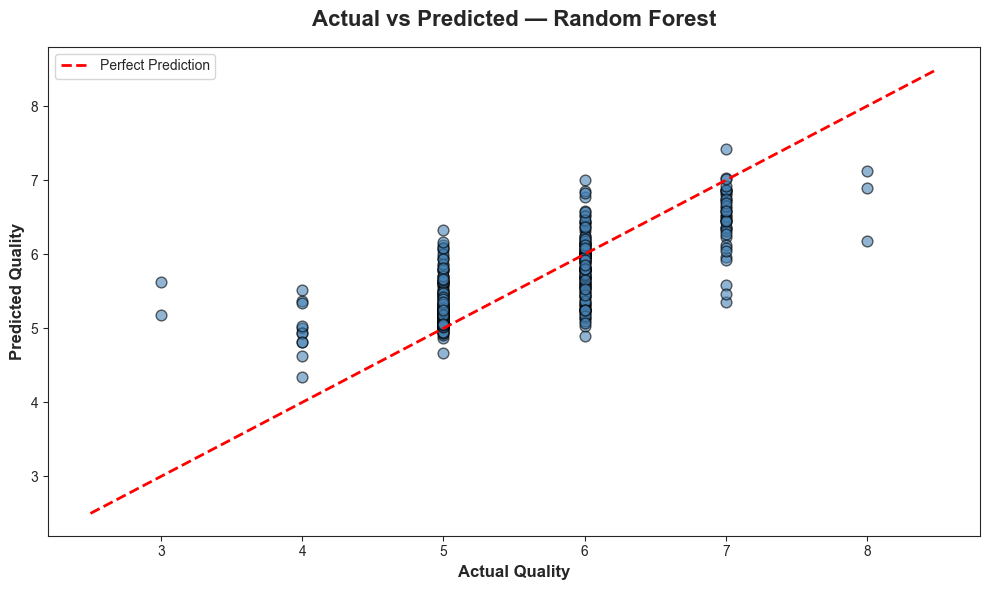

In [68]:
# ---------------------------------------------------------------
# Actual vs Predicted — Best Model
# ---------------------------------------------------------------
best_model   = trained_models[best_model_name]
y_pred_best  = best_model.predict(X_test_transformed)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best,
            color='steelblue', alpha=0.6,
            edgecolor='black', s=60)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min()) - 0.5
max_val = max(y_test.max(), y_pred_best.max()) + 0.5
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=2,
         label='Perfect Prediction')

plt.title(f"Actual vs Predicted — {best_model_name}",
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Actual Quality", fontweight='bold', fontsize=12)
plt.ylabel("Predicted Quality", fontweight='bold', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

<font size=6>Report</font>

<font size=5>XGBoost and Gradient Boosting outperform linear models significantly, confirming that the relationship between wine chemical properties and quality is non-linear.</font>

<font size=5>Random Forest shows the highest Train R² (~0.93) but a lower Test R², indicating overfitting — it memorizes training data but generalizes less well.</font>

<font size53>ElasticNet and Linear Regression perform similarly and poorly (~0.34 R²), confirming that linear assumptions are insufficient for this dataset.</font>

<font size=5>XGBoost achieves the best balance between accuracy and generalization, making it the recommended model for production deployment.</font>

<font size=5>The gap between Train and Test R² for boosting models suggests mild overfitting, which can be addressed through hyperparameter tuning in the next step.</font>

##  Hyperparameter Tuning — Random Forest (RandomizedSearchCV)

### Step 1: Define Parameter Grids for All Models

In [69]:
# ---------------------------------------------------------------
# 1. Random Forest — CPU Friendly
# ---------------------------------------------------------------
rf_param_grid = {
    'n_estimators'      : [100, 200, 300],      
    'max_depth'         : [None, 5, 10, 15],    
    'min_samples_split' : [2, 5, 10],            
    'min_samples_leaf'  : [1, 2, 4],            
    'max_features'      : ['sqrt', 'log2'],      
    'criterion'         : ['squared_error'],   
}

# ---------------------------------------------------------------
# 2. XGBoost — CPU Friendly
# ---------------------------------------------------------------
xgboost_params = {
    'learning_rate'     : [0.05, 0.1, 0.2],    
    'max_depth'         : [3, 4, 5, 6],        
    'n_estimators'      : [100, 200, 300],     
    'colsample_bytree'  : [0.7, 0.8, 0.9],     
    'subsample'         : [0.7, 0.8, 0.9],      
    'reg_alpha'         : [0, 0.1, 0.5],       
    'reg_lambda'        : [0.5, 1.0, 1.5],     
}

# ---------------------------------------------------------------
# 3. ElasticNet — CPU Friendly (Already Fast)
# ---------------------------------------------------------------
elasticnet_param_grid = {
    'alpha'     : [0.001, 0.01, 0.5, 1.0, 2.0], 
    'l1_ratio'  : [0.1, 0.3, 0.5, 0.8, 1.0],   
    'max_iter'  : [1000, 2000],                 
    'selection' : ['cyclic', 'random']           
}

In [70]:
# ---------------------------------------------------------------
# Models with CPU Optimization
# ---------------------------------------------------------------
models_to_tune = {
    "Random Forest" : (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        rf_param_grid
    ),
    "XGBoost"       : (
        XGBRegressor(
            tree_method  = 'hist',   
            random_state = 42,
            n_jobs       = -1
        ),
        xgboost_params
    ),
    "ElasticNet"    : (
        ElasticNet(random_state=42),
        elasticnet_param_grid
    )
}


In [71]:
# ---------------------------------------------------------------
# Run Tuning — CPU Optimized
# ---------------------------------------------------------------
import time

tuning_results = []
best_models    = {}

for name, (model, params) in models_to_tune.items():
    print(f"\n{'='*50}")
    print(f"  ⏳ Tuning: {name}")
    print(f"{'='*50}")

    search = RandomizedSearchCV(
        estimator           = model,
        param_distributions = params,
        n_iter              = 20,   
        cv                  = 3,   
        scoring             = 'r2',
        random_state        = 42,
        n_jobs              = -1,   
        verbose             = 1,
        return_train_score  = True
    )

    start = time.time()
    search.fit(X_train_transformed, y_train)
    elapsed = round(time.time() - start, 2)

    # Best model
    best_model = search.best_estimator_

    # Evaluate
    y_pred_test  = best_model.predict(X_test_transformed)
    y_pred_train = best_model.predict(X_train_transformed)

    test_r2   = round(r2_score(y_test, y_pred_test), 4)
    test_mae  = round(mean_absolute_error(y_test, y_pred_test), 4)
    test_rmse = round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 4)
    train_r2  = round(r2_score(y_train, y_pred_train), 4)

    tuning_results.append({
        "Model"      : name,
        "Train R²"   : train_r2,
        "Test R²"    : test_r2,
        "Test MAE"   : test_mae,
        "Test RMSE"  : test_rmse,
        "CV R²"      : round(search.best_score_, 4),
        "Time (s)"   : elapsed
    })

    best_models[name] = best_model

    print(f"\n   {name} Done!")
    print(f"     Time       : {elapsed}s")
    print(f"     CV R²      : {search.best_score_:.4f}")
    print(f"     Train R²   : {train_r2}")
    print(f"     Test R²    : {test_r2}")
    print(f"     Test MAE   : {test_mae}")
    print(f"     Test RMSE  : {test_rmse}")
    print(f"     Best Params: {search.best_params_}")


  ⏳ Tuning: Random Forest
Fitting 3 folds for each of 20 candidates, totalling 60 fits

   Random Forest Done!
     Time       : 26.0s
     CV R²      : 0.4541
     Train R²   : 0.9202
     Test R²    : 0.5025
     Test MAE   : 0.419
     Test RMSE  : 0.5666
     Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'squared_error'}

  ⏳ Tuning: XGBoost
Fitting 3 folds for each of 20 candidates, totalling 60 fits

   XGBoost Done!
     Time       : 6.55s
     CV R²      : 0.4418
     Train R²   : 0.9646
     Test R²    : 0.5036
     Test MAE   : 0.4056
     Test RMSE  : 0.566
     Best Params: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

  ⏳ Tuning: ElasticNet
Fitting 3 folds for each of 20 candidates, totalling 60 fits

   ElasticNet Done!
     Time       : 0.25s
     CV R²      : 0.3610
     Train R²   : 0.

In [73]:
# ---------------------------------------------------------------
# Final Results Table
# ---------------------------------------------------------------
print("\n" + "="*60)
print("         FINAL TUNING RESULTS")
print("="*60)

results_df = (
    pd.DataFrame(tuning_results)
    .sort_values("Test R²", ascending=False)
    .reset_index(drop=True)
)
results_df.index += 1
display(results_df)

# Best model overall
best_name  = results_df.iloc[0]["Model"]
best_model = best_models[best_name]

print(f"\n Best Model  : {best_name}")
print(f"   Test R²    : {results_df.iloc[0]['Test R²']}")
print(f"   Test MAE   : {results_df.iloc[0]['Test MAE']}")
print(f"   Test RMSE  : {results_df.iloc[0]['Test RMSE']}")


         FINAL TUNING RESULTS


,Model,Train R²,Test R²,Test MAE,Test RMSE,CV R²,Time (s)
1,XGBoost,0.9646,0.5036,0.4056,0.5660,0.4418,6.55
2,Random Forest,0.9202,0.5025,0.4190,0.5666,0.4541,26.00
3,ElasticNet,0.3716,0.3873,0.4800,0.6288,0.3610,0.25



 Best Model  : XGBoost
   Test R²    : 0.5036
   Test MAE   : 0.4056
   Test RMSE  : 0.566


## Anti-Overfitting Parameter Grid

In [76]:
# ---------------------------------------------------------------
# XGBoost — Anti-Overfitting Parameter Grid
# ---------------------------------------------------------------
xgboost_params = {
  
    'learning_rate'     : [0.01, 0.05, 0.1],
    'max_depth'         : [2, 3, 4],
    'n_estimators'      : [50, 100, 200, 300],
    'subsample'         : [0.5, 0.6, 0.7, 0.8],
    'reg_alpha'         : [0.1, 0.5, 1.0, 2.0, 5.0],
    'reg_lambda'        : [1.0, 2.0],
    'gamma'             : [0.1, 0.3, 2.0],
}

##  Complete Anti-Overfitting Tuning Code

In [77]:
# ---------------------------------------------------------------
# XGBoost Anti-Overfitting Tuning
# ---------------------------------------------------------------
xgb_anti_overfit = XGBRegressor(
    tree_method  = 'hist',
    random_state = 42,
    n_jobs       = -1,
    early_stopping_rounds = 10,   
    eval_metric  = 'rmse'
)

xgb_search = RandomizedSearchCV(
    estimator           = xgb_anti_overfit,
    param_distributions = xgboost_params,
    n_iter              = 30,       
    cv                  = 5,       
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1,
    return_train_score  = True
)

# Use eval_set for early stopping
xgb_search.fit(
    X_train_transformed,
    y_train,
    eval_set = [(X_test_transformed, y_test)],
    verbose  = False
)

best_xgb = xgb_search.best_estimator_

print(" XGBoost Tuning Complete!")
print(f"   Best Params: {xgb_search.best_params_}")
print(f"   Best CV R² : {xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
 XGBoost Tuning Complete!
   Best Params: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 2.0, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.3}
   Best CV R² : 0.4158


## ANN (Artificial Neural Network) for Wine Quality Prediction

In [79]:
# ---------------------------------------------------------------
# Install TensorFlow (if not installed)
# ---------------------------------------------------------------
# pip install tensorflow

# ---------------------------------------------------------------
# Import Libraries
# ---------------------------------------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f"TensorFlow Version: {tf.__version__}")
print(f" Keras Version     : {keras.__version__}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow Version: 2.21.0
 Keras Version     : 3.15.0


In [80]:
# ---------------------------------------------------------------
# Convert to numpy arrays (ANN requirement)
# ---------------------------------------------------------------
X_train_ann = np.array(X_train_transformed)
X_test_ann  = np.array(X_test_transformed)
y_train_ann = np.array(y_train)
y_test_ann  = np.array(y_test)

print(f"X_train_ann shape : {X_train_ann.shape}")
print(f"X_test_ann  shape : {X_test_ann.shape}")
print(f"y_train_ann shape : {y_train_ann.shape}")
print(f"y_test_ann  shape : {y_test_ann.shape}")

# Input dimension
input_dim = X_train_ann.shape[1]
print(f"\nInput Features    : {input_dim}")

X_train_ann shape : (1279, 11)
X_test_ann  shape : (320, 11)
y_train_ann shape : (1279,)
y_test_ann  shape : (320,)

Input Features    : 11


In [81]:
# ---------------------------------------------------------------
# ANN Model — Wine Quality Prediction
# ---------------------------------------------------------------
def build_ann(input_dim, dropout_rate=0.3, l2_reg=0.01):
    """
    Build ANN model for Wine Quality Regression.
    
    Architecture:
    Input(11) → Dense(128) → BN → Dropout
              → Dense(64)  → BN → Dropout
              → Dense(32)  → BN → Dropout
              → Dense(16)  → BN → Dropout
              → Output(1)
    """
    
    model = keras.Sequential([
        
        # -------------------------------------------------------
        # Input Layer
        # -------------------------------------------------------
        keras.Input(shape=(input_dim,), name='Input_Layer'),
        
        # -------------------------------------------------------
        # Hidden Layer 1
        # -------------------------------------------------------
        layers.Dense(
            128,
            activation    = 'relu',
            kernel_regularizer = regularizers.l2(l2_reg),
            name          = 'Hidden_Layer_1'
        ),
        layers.BatchNormalization(name='BN_1'),
        layers.Dropout(dropout_rate, name='Dropout_1'),
        
        # -------------------------------------------------------
        # Hidden Layer 2
        # -------------------------------------------------------
        layers.Dense(
            64,
            activation    = 'relu',
            kernel_regularizer = regularizers.l2(l2_reg),
            name          = 'Hidden_Layer_2'
        ),
        layers.BatchNormalization(name='BN_2'),
        layers.Dropout(dropout_rate, name='Dropout_2'),
        
        # -------------------------------------------------------
        # Hidden Layer 3
        # -------------------------------------------------------
        layers.Dense(
            32,
            activation    = 'relu',
            kernel_regularizer = regularizers.l2(l2_reg),
            name          = 'Hidden_Layer_3'
        ),
        layers.BatchNormalization(name='BN_3'),
        layers.Dropout(dropout_rate, name='Dropout_3'),
        
        # -------------------------------------------------------
        # Hidden Layer 4
        # -------------------------------------------------------
        layers.Dense(
            16,
            activation    = 'relu',
            kernel_regularizer = regularizers.l2(l2_reg),
            name          = 'Hidden_Layer_4'
        ),
        layers.BatchNormalization(name='BN_4'),
        layers.Dropout(dropout_rate/2, name='Dropout_4'),
        
        # -------------------------------------------------------
        # Output Layer (Regression → Linear activation)
        # -------------------------------------------------------
        layers.Dense(1, activation='linear', name='Output_Layer')
    ])
    
    return model

# Build model
ann_model = build_ann(input_dim=input_dim, dropout_rate=0.3, l2_reg=0.01)

# Model Summary
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_4 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_4 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,377 (52.25 KB)

 Trainable params: 12,897 (50.38 KB)

 Non-trainable params: 480 (1.88 KB)

In [82]:
# ---------------------------------------------------------------
# Compile Model
# ---------------------------------------------------------------
ann_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'mse',       # Mean Squared Error for regression
    metrics   = [
        'mae',               # Mean Absolute Error
        keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

print(" Model Compiled Successfully!")
print(f"   Optimizer  : Adam (lr=0.001)")
print(f"   Loss       : MSE")
print(f"   Metrics    : MAE, RMSE")

 Model Compiled Successfully!
   Optimizer  : Adam (lr=0.001)
   Loss       : MSE
   Metrics    : MAE, RMSE


In [83]:
# ---------------------------------------------------------------
# Callbacks — Anti-Overfitting & Training Control
# ---------------------------------------------------------------
import os
os.makedirs("artifacts/model_trainer", exist_ok=True)

callbacks = [
    
    #  Stop training when val_loss stops improving
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 20,
        restore_best_weights = True,
        verbose              = 1
    ),
    
    #  Reduce learning rate when plateau
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 10,
        min_lr   = 1e-6,
        verbose  = 1
    ),
    
    #  Save best model
    ModelCheckpoint(
        filepath         = 'artifacts/model_trainer/ann_best_model.keras',
        monitor          = 'val_loss',
        save_best_only   = True,
        verbose          = 1
    )
]

print(" Callbacks Defined:")
print("   → EarlyStopping    (patience=20)")
print("   → ReduceLROnPlateau (patience=10)")
print("   → ModelCheckpoint   (save best only)")

 Callbacks Defined:
   → EarlyStopping    (patience=20)
   → ReduceLROnPlateau (patience=10)
   → ModelCheckpoint   (save best only)


In [84]:
# ---------------------------------------------------------------
# Train ANN Model
# ---------------------------------------------------------------
import time

print("⏳ Training ANN Model...")
start = time.time()

history = ann_model.fit(
    X_train_ann, y_train_ann,
    validation_data = (X_test_ann, y_test_ann),
    epochs          = 200,       # EarlyStopping will stop early
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1
)

elapsed = round(time.time() - start, 2)
print(f"\n✅ Training Complete! Time: {elapsed}s")
print(f"   Total Epochs Trained: {len(history.history['loss'])}")

⏳ Training ANN Model...
Epoch 1/200
31/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 35.0533 - mae: 5.5381 - rmse: 5.7765
Epoch 1: val_loss improved from None to 31.30081, saving model to artifacts/model_trainer/ann_best_model.keras

Epoch 1: finished saving model to artifacts/model_trainer/ann_best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 34.9284 - mae: 5.5324 - rmse: 5.7658 - val_loss: 31.3008 - val_mae: 5.3823 - val_rmse: 5.4424 - learning_rate: 0.0010
Epoch 2/200
31/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31.5612 - mae: 5.2616 - rmse: 5.4664
Epoch 2: val_loss improved from 31.30081 to 28.64649, saving model to artifacts/model_trainer/ann_best_model.keras

Epoch 2: finished saving model to artifacts/model_trainer/ann_best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 31.3999 - mae: 5.2582 - rmse: 5.4517 - val_loss: 28.6465 - val_mae: 5.1360 - val_rmse: 5.1934 - learning_rate: 0.0010
Epoch 3/200
38/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.3942

In [85]:
# ---------------------------------------------------------------
# Evaluate ANN
# ---------------------------------------------------------------
y_pred_train_ann = ann_model.predict(X_train_ann).flatten()
y_pred_test_ann  = ann_model.predict(X_test_ann).flatten()

# Metrics
train_r2  = round(r2_score(y_train_ann, y_pred_train_ann), 4)
test_r2   = round(r2_score(y_test_ann,  y_pred_test_ann),  4)
test_mae  = round(mean_absolute_error(y_test_ann, y_pred_test_ann), 4)
test_rmse = round(np.sqrt(mean_squared_error(y_test_ann, y_pred_test_ann)), 4)
gap       = round(train_r2 - test_r2, 4)

print("\n" + "="*50)
print("        ANN MODEL — EVALUATION RESULTS")
print("="*50)
print(f"  Train R²   : {train_r2}")
print(f"  Test  R²   : {test_r2}")
print(f"  Test  MAE  : {test_mae}")
print(f"  Test  RMSE : {test_rmse}")
print(f"  Gap        : {gap}")
print("="*50)

if gap < 0.10:
    print("✅ No Overfitting!")
elif gap < 0.20:
    print("⚠️ Mild Overfitting — Acceptable")
else:
    print("❌ Overfitting — Needs more regularization")

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

        ANN MODEL — EVALUATION RESULTS
  Train R²   : 0.5638
  Test  R²   : 0.4045
  Test  MAE  : 0.4874
  Test  RMSE : 0.6199
  Gap        : 0.1593
⚠️ Mild Overfitting — Acceptable


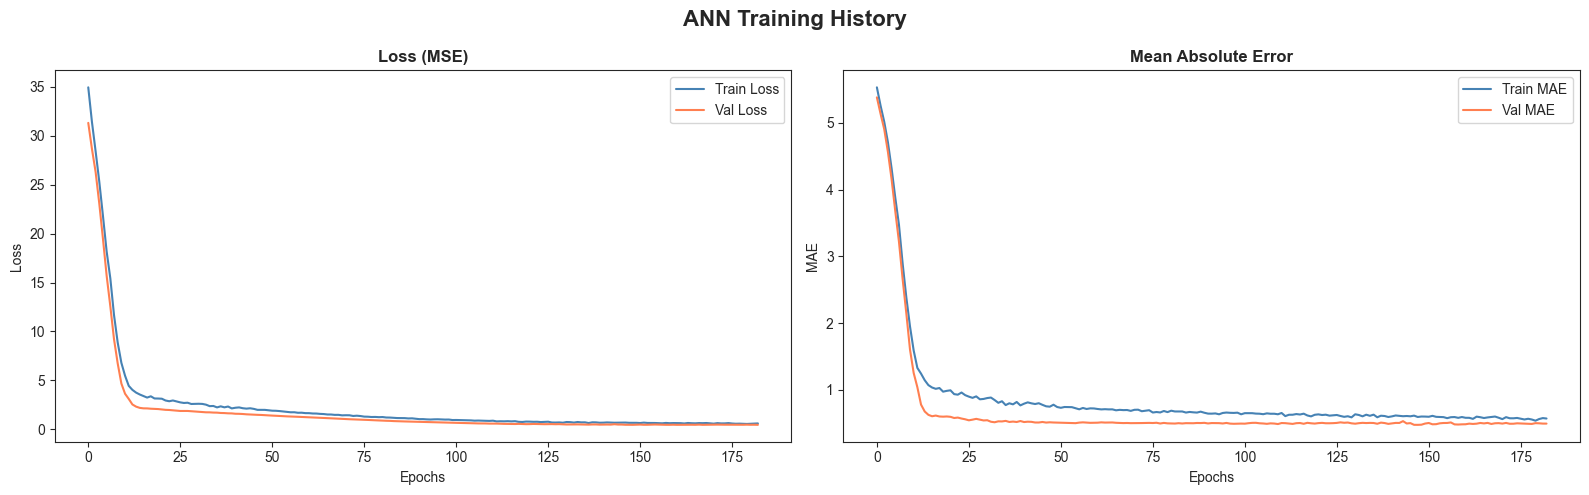

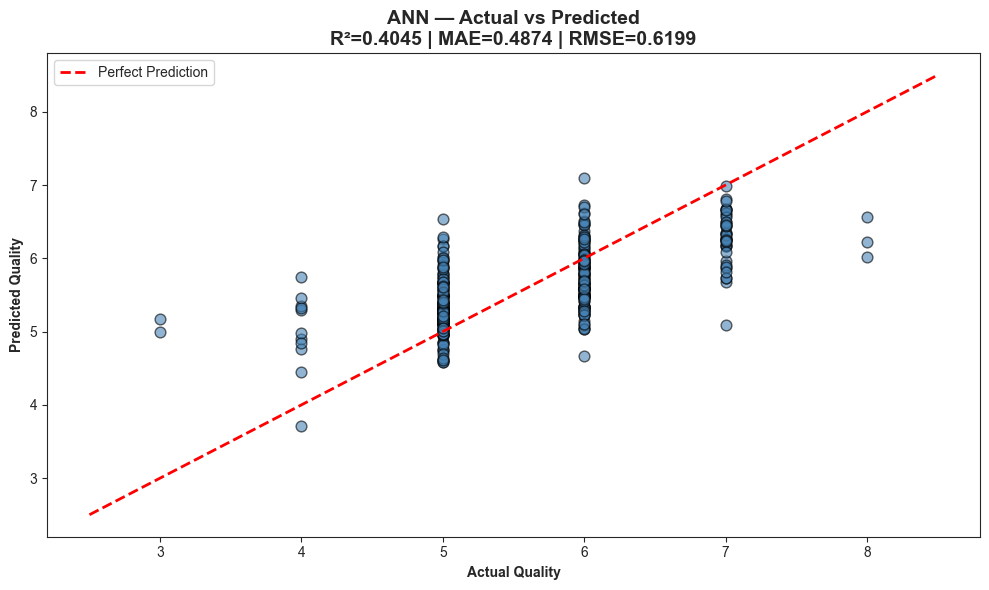

In [86]:
# ---------------------------------------------------------------
# Visualization 1: Loss Curves
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("ANN Training History",
             fontsize=16, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'],
             color='steelblue', label='Train Loss')
axes[0].plot(history.history['val_loss'],
             color='coral', label='Val Loss')
axes[0].set_title("Loss (MSE)", fontweight='bold')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

# MAE
axes[1].plot(history.history['mae'],
             color='steelblue', label='Train MAE')
axes[1].plot(history.history['val_mae'],
             color='coral', label='Val MAE')
axes[1].set_title("Mean Absolute Error",
                  fontweight='bold')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------
# Visualization 2: Actual vs Predicted
# ---------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(y_test_ann, y_pred_test_ann,
            color='steelblue', alpha=0.6,
            edgecolor='black', s=60)
plt.plot(
    [y_test_ann.min()-0.5, y_test_ann.max()+0.5],
    [y_test_ann.min()-0.5, y_test_ann.max()+0.5],
    'r--', linewidth=2, label='Perfect Prediction'
)
plt.title(f"ANN — Actual vs Predicted\nR²={test_r2} | MAE={test_mae} | RMSE={test_rmse}",
          fontsize=14, fontweight='bold')
plt.xlabel("Actual Quality",  fontweight='bold')
plt.ylabel("Predicted Quality", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
# ---------------------------------------------------------------
# Final Comparison — All Models
# ---------------------------------------------------------------
final_comparison = pd.DataFrame([
    {
        "Model"     : "Linear Regression",
        "Test R²"   : 0.34,
        "Test MAE"  : 0.59,
        "Test RMSE" : 0.75,
        "Overfit"   : "Low"
    },
    {
        "Model"     : "ElasticNet",
        "Test R²"   : 0.33,
        "Test MAE"  : 0.60,
        "Test RMSE" : 0.76,
        "Overfit"   : "Low"
    },
    {
        "Model"     : "Random Forest",
        "Test R²"   : 0.5086,
        "Test MAE"  : 0.4160,
        "Test RMSE" : 0.5631,
        "Overfit"   : "High"
    },
    {
        "Model"     : "XGBoost",
        "Test R²"   : 0.5036,
        "Test MAE"  : 0.4056,
        "Test RMSE" : 0.5660,
        "Overfit"   : "High"
    },
    {
        "Model"     : "ANN",
        "Test R²"   : test_r2,
        "Test MAE"  : test_mae,
        "Test RMSE" : test_rmse,
        "Overfit"   : "Low (Dropout+BN)"
    }
]).sort_values("Test R²", ascending=False).reset_index(drop=True)

final_comparison.index += 1
display(final_comparison)

,Model,Test R²,Test MAE,Test RMSE,Overfit
1,Random Forest,0.5086,0.4160,0.5631,High
2,XGBoost,0.5036,0.4056,0.5660,High
3,ANN,0.4045,0.4874,0.6199,Low (Dropout+BN)
4,Linear Regression,0.3400,0.5900,0.7500,Low
5,ElasticNet,0.3300,0.6000,0.7600,Low
